In [1]:
import sys
import xarray as xr
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import importlib as imp
import pandas as pd
import warnings

from sklearn import metrics
import scipy.stats as stats

from utils import utils
import utils.load_utils as load_utils
import visuals.plotting as plotting
import data_loader.data_loaders as data_loader
import cmasher as cm
from data_loader.data_loaders import MapToValueData
from data_loader.sample_vault import SampleDict

from utils.DIRECTORIES import DATA_DIRECTORY, SHAPE_DIRECTORY

warnings.filterwarnings("ignore")
torch.set_warn_always(False)

print(f"python version = {sys.version}")
print(f"numpy version = {np.__version__}")
print(f"xarray version = {xr.__version__}")
print(f"pytorch version = {torch.__version__}")

/Users/senne/anaconda3/envs/env_pt/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


python version = 3.13.2 | packaged by Anaconda, Inc. | (main, Feb  6 2025, 12:55:35) [Clang 14.0.6 ]
numpy version = 2.2.4
xarray version = 2024.11.0
pytorch version = 2.7.0


In [2]:
SAVE_FIGS = False

# window for regression
n_time = 30

# Set to 'nino34' to use observations with nino34 linearly removed.
# enso = 'nino34'
enso = False

## Load data & model

In [3]:
OVERWRITE = False
imp.reload(utils)
imp.reload(load_utils)
imp.reload(data_loader)

NETW_NAME = "tas2Rg_amip_trend_random"
seed = 0
# NETW_NAME = "tas2Rg_all_trend"
# seed = 0

# Load model and data
model_dct = {}
model_dct['network'] = {}
(
    model_dct['network']['config'],
    model_dct['network']['model'],
    _,
    _,
    _,
    model_dct['network']['testset'],
) = load_utils.load_model_and_data(NETW_NAME, seed, verbose=False)

DATA_NAMES = (
    "tas2Rg_amip_data",
    "tas2Rg_amip_extended_E3SM",
    "tas2Rg_amip_extended_HadGEM",
    # "tas2Rg_amip_extended_E3SM-HadISST",
    # "tas2Rg_amip_extended_E3SM_F2010_NEP",
)
DATA_LBLS = (
    'CFMIP', 
    'E3SMv2', 
    'HadGEM3', 
    # 'E3SM-HadISST', 
    # 'E3SM-noNEP',
)
for DATA_NAME in DATA_NAMES:
    model_dct[DATA_NAME] = {}
    (
        model_dct[DATA_NAME]['config'],
        model_dct[DATA_NAME]['data'],
        _,
        _,
        model_dct[DATA_NAME]['testset'],
    ) = load_utils.load_data(DATA_NAME, seed, verbose=False)

lon, lat = model_dct[DATA_NAME]['data'].input_lon, model_dct[DATA_NAME]['data'].input_lat

# Observational data
OBS_NAMES = (
    "era5",
    "merra2",
    "jra3q",
    "noaaglobaltemp",
    "berkeleyearth",
    "hadcrut5",
    "dcent",
)
obs_dict = {}
for obs_name in OBS_NAMES:
    OBS_DATA_NAME = "tas_" + obs_name
    obs_dict[obs_name] = {}

    (
        obs_dict[obs_name]['config'],
        obs_dict[obs_name]['data'],
        obs_dict[obs_name]['dataset'],
    ) = load_utils.load_obs_data(
        OBS_DATA_NAME,
        seed,
        verbose=False,
        anomaly_dates = model_dct['network']['config']['datamaker']['anomaly_dates']
    )


    if enso:
        obs_dict[obs_name]['config']['expname'] = obs_dict[obs_name]['config']['expname'] + '_no_' + enso

        if obs_name == 'noaaglobaltemp' and enso == 'pdo':
            obs_dict[obs_name]['config']['datamaker']['data_period'] = '_no_pdo_1854-2025'
        else:
            obs_dict[obs_name]['config']['datamaker']['data_period'] = '_no_' + enso + obs_dict[obs_name]['config']['datamaker']['data_period']

        (
            obs_dict[obs_name]['config'],
            obs_dict[obs_name]['data'],
            obs_dict[obs_name]['dataset'],
        ) = load_utils.load_obs_data(
            OBS_DATA_NAME, seed, verbose=False, 
            config = obs_dict[obs_name]['config'],
        )

## Make predictions and get global mean T

In [5]:
# AMIP data
for DATA_NAME in DATA_NAMES:

    # Global mean temperature
    (
        _,
        _,
        model_dct[DATA_NAME]['data'].d_test['x_gm'],
        weights
    ) = load_utils.get_global_mean_input(model_dct[DATA_NAME]['config'], seed)
    n_models = len(model_dct[DATA_NAME]['config']['datamaker']['models'])
    n_mems = model_dct[DATA_NAME]['config']['datamaker']['n_train_val_test'][2]

    # Save number of models and ensemble members per dataset
    model_dct[DATA_NAME]['n_models'] = n_models
    model_dct[DATA_NAME]['n_mems'] = n_mems

    # Predicted R
    GM_true = model_dct[DATA_NAME]['data'].d_test['y']
    GM_pred = load_utils.make_predictions(
        model_dct['network']['model'], 
        dataset=model_dct[DATA_NAME]['testset'], 
        device='mps'
    )

    # Save data to dict
    model_dct[DATA_NAME]['R_true'] = GM_true.reshape((n_models,n_mems,-1))
    model_dct[DATA_NAME]['R_pred'] = GM_pred.reshape((n_models,n_mems,-1))

    model_dct[DATA_NAME]['year'] = model_dct[DATA_NAME]['data'].d_test['year'].reshape((n_models,n_mems,-1))[0,0,:]
    model_dct[DATA_NAME]['Tg'] = model_dct[DATA_NAME]['data'].d_test['x_gm'].reshape((n_models,n_mems,-1))

# Observational T
for obs_name in OBS_NAMES:

    # Global mean temperature
    (
        obs_dict[obs_name]['data'].d_obs['x_gm'], 
        weights 
    ) = load_utils.get_global_mean_obs(obs_dict[obs_name]['config'], seed)


    # Predictions
    GM_pred = load_utils.make_predictions(
        model_dct['network']['model'], 
        dataset=obs_dict[obs_name]['dataset'], 
        device='mps'
    )

    # Save data to dict
    obs_dict[obs_name]['year'] = obs_dict[obs_name]['data'].d_obs['year'][0,:]
    obs_dict[obs_name]['Tg'] = obs_dict[obs_name]['data'].d_obs['x_gm'][:,0]
    
    obs_dict[obs_name]['R_pred'] = GM_pred[:,0]

## Plot $R$ and $T_g$

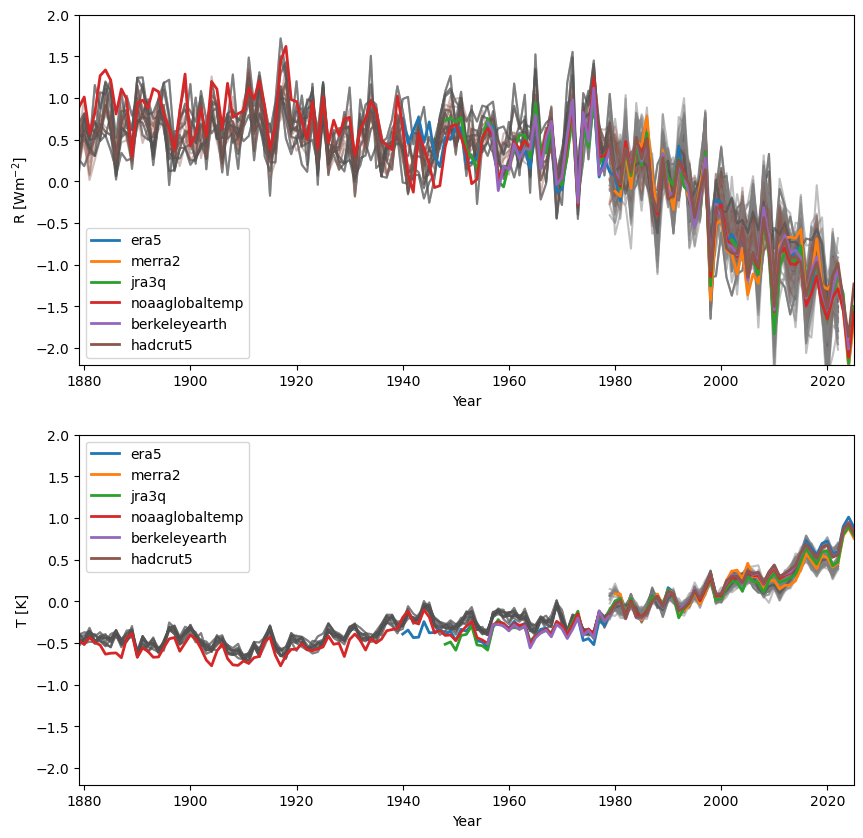

In [23]:
fig, ax = plt.subplots(2,1,figsize=(10,10))

# AMIP data
for DATA_NAME in DATA_NAMES:
    for jj, model in enumerate(model_dct[DATA_NAME]['config']['datamaker']['models']):

        # Ensemble mean
        ax[1].plot(model_dct[DATA_NAME]['year'], model_dct[DATA_NAME]['Tg'].mean(axis=1)[jj,:],'k',alpha=0.5)
        ax[0].plot(model_dct[DATA_NAME]['year'], model_dct[DATA_NAME]['R_true'].mean(axis=1)[jj,:],'k',alpha=0.5)

        # Individual members
        for mm in range(model_dct[DATA_NAME]['n_mems']):
            ax[1].plot(model_dct[DATA_NAME]['year'], model_dct[DATA_NAME]['Tg'][jj,mm,:],'gray',alpha=0.5)

            ax[0].plot(model_dct[DATA_NAME]['year'], model_dct[DATA_NAME]['R_true'][jj,mm,:],'gray',alpha=0.5)
            ax[0].plot(model_dct[DATA_NAME]['year'], model_dct[DATA_NAME]['R_pred'][jj,mm,:], plotting.npcols[5],alpha=0.4)

# Obs data
yr_all = np.arange(1850,2026)
R_all = np.full((len(OBS_NAMES), len(yr_all)),np.nan)
T_all = np.full((len(OBS_NAMES), len(yr_all)),np.nan)
for jj, obs_name in enumerate(OBS_NAMES):
    ax[0].plot(
        obs_dict[obs_name]['year'], 
        obs_dict[obs_name]['R_pred'], 
        label=obs_name,
        linewidth=2,color=plotting.npcols[jj]
    )

    ax[1].plot(
        obs_dict[obs_name]['year'], 
        obs_dict[obs_name]['Tg'], 
        label=obs_name,
        linewidth=2,color=plotting.npcols[jj]
    )


    # Save to common array
    iy_ = np.where(
        (yr_all >= obs_dict[obs_name]['year'][0]) & 
        (yr_all <= obs_dict[obs_name]['year'][-1])
    )[0]
    R_all[jj,iy_] = obs_dict[obs_name]['R_pred']
    T_all[jj,iy_] = obs_dict[obs_name]['Tg']

obs_dict['all_yrs'] = yr_all
obs_dict['all_R'] = R_all
obs_dict['all_T'] = T_all

ax[0].set_ylabel("R [Wm$^{-2}$]")
ax[1].set_ylabel("T [K]")
for ii in range(2):
    ax[ii].legend()
    ax[ii].set_xlabel("Year")
    ax[ii].set_xlim(1879,2025)
    ax[ii].set_ylim(-2.2,2)

## 30-year regression

In [10]:
# AMIP data
for DATA_NAME in DATA_NAMES:

    # Load T and R
    T = model_dct[DATA_NAME]['Tg']
    true = model_dct[DATA_NAME]['R_true']
    pred = model_dct[DATA_NAME]['R_pred']

    n_models,n_mems,num_y = T.shape[:3]

    # Compute linear regression coefficients
    l_true = np.empty((n_models,n_mems,num_y-n_time+1))
    l_pred = np.empty((n_models,n_mems,num_y-n_time+1))
    for ii in range(n_models):
        for jj in range(n_mems):
            for iy in range(num_y-n_time+1):
                l_true[ii,jj,iy], _ = utils.linear_regression(T[ii,jj,iy:iy+n_time],true[ii,jj,iy:iy+n_time])
                l_pred[ii,jj,iy], _ = utils.linear_regression(T[ii,jj,iy:iy+n_time],pred[ii,jj,iy:iy+n_time])
    model_dct[DATA_NAME]['l_true'] = l_true
    model_dct[DATA_NAME]['l_pred'] = l_pred

# Observational data
all_l_yrs = np.arange(1850+n_time-1,2026)
all_l_obs = np.full((len(OBS_NAMES),all_l_yrs.size),np.nan)
for ii, obs_name in enumerate(OBS_NAMES):

    # Load T and R
    T = obs_dict[obs_name]['Tg']
    pred = obs_dict[obs_name]['R_pred']

    num_y = T.shape[0]

    # Compute linear regression coefficients
    l_pred = np.empty((num_y-n_time+1))
    for iy in range(num_y-n_time+1):
        l_pred[iy], _ = utils.linear_regression(T[iy:iy+n_time],pred[iy:iy+n_time])
    obs_dict[obs_name]['l_pred'] = l_pred

    # Corresponding years
    l_year = obs_dict[obs_name]['year'][n_time-1:]
    obs_dict[obs_name]['l_year'] = l_year

    # Save to common array
    iy_ = np.where(
        (all_l_yrs >= obs_dict[obs_name]['l_year'][0]) & 
        (all_l_yrs <= obs_dict[obs_name]['l_year'][-1])
    )[0]
    all_l_obs[ii,iy_] = obs_dict[obs_name]['l_pred']
        
obs_dict['all_l_yrs'] = all_l_yrs
obs_dict['all_l_obs'] = all_l_obs

# Overlapping years
i_all = np.where(~np.isnan(obs_dict['all_l_obs'].mean(axis=0)))[0]
obs_dict['all_l_yrs_overlap'] = all_l_yrs[i_all]
obs_dict['all_l_obs_overlap'] = obs_dict['all_l_obs'][:,i_all]

### CERES

In [41]:
Forster_df=pd.read_csv(DATA_DIRECTORY+"../data/obs/ERF_best_1750-2024.csv",sep=",")
Forster_y = Forster_df['year'].to_numpy()
Forster_F = Forster_df.loc[:, Forster_df.columns != 'year'].sum(axis=1).to_numpy()
Forster_iy = np.where(\
    (Forster_y >= 2001) & \
    (Forster_y <= 2020)
)[0]
Forster_F = Forster_F - np.mean(Forster_F[Forster_iy])

ds_CERES = xr.open_dataarray(DATA_DIRECTORY+"../data/obs/deepC+CERES_1985-2024.nc")

CERES_y = ds_CERES['year'].values
CERES_N = ds_CERES.values
CERES_iy = np.where(\
    (CERES_y >= 2001) & \
    (CERES_y <= 2020)
)[0]
CERES_N = CERES_N - np.mean(CERES_N[CERES_iy])

Forster_N_iy = np.where(\
    (Forster_y >= 1985) & \
    (Forster_y <= 2024)
)[0]

CERES_R = CERES_N - Forster_F[Forster_N_iy]


CERES_dct = {}

CERES_dct['year'] = CERES_y
CERES_dct['N'] = CERES_N
CERES_dct['F'] = Forster_F[Forster_N_iy]
CERES_dct['R'] = CERES_R

l_CERES = np.empty((len(OBS_NAMES),CERES_R.shape[0]-n_time+1))
num_y = CERES_R.shape[0]

# Observational data
for ii, obs_name in enumerate(OBS_NAMES):

    # Load T
    T = obs_dict[obs_name]['Tg']
    yr = obs_dict[obs_name]['year']
    iy_clim = np.where(\
        (yr >= 2001) & \
        (yr <= 2020)
    )[0]
    T = T - np.mean(T[iy_clim])

    # Select same years as CERES
    iy_ = np.where(\
        (yr >= 1985) & \
        (yr <= 2024)
    )[0]
    T = T[iy_].copy()
    yrs = yr[iy_].copy()

    # Compute linear regression coefficients
    for iy in range(num_y-n_time+1):
        yr_ = yrs[iy:iy+n_time]
        T_ = T[iy:iy+n_time]
        R_ = CERES_R[iy:iy+n_time]

        l_CERES[ii,iy], _ = utils.linear_regression(T_,R_)
CERES_dct['l'] = l_CERES

## SHAP values

In [12]:
# AMIP data
for dj, (DATA_NAME, DATA_LBL) in enumerate(zip(
    DATA_NAMES, DATA_LBLS
)):

    # Get values
    T_all =  model_dct[DATA_NAME]['Tg'].copy()
    n_models, n_mems, num_y = T_all.shape

    tas_all =  model_dct[DATA_NAME]['data'].d_test['x'].reshape((n_models,n_mems,num_y,1,lat.size,lon.size))
    
    years =  model_dct[DATA_NAME]['year'].copy()

    # Yearly SHAP
    shap = load_utils.deep_shap(
        model_dct['network']['model'], 
        model_dct[DATA_NAME]['testset'], 
        baseline=None, device="cpu"
    ).reshape((n_models,n_mems,num_y,tas_all.shape[4],tas_all.shape[5]))

    # Save SHAP values
    model_dct[DATA_NAME]['shap'] = shap

    # Initialize arrays
    T_pattern = np.full((n_models,n_mems,num_y-n_time+1,lat.size,lon.size),np.nan)
    shap_pattern = np.full((n_models,n_mems,num_y-n_time+1,lat.size,lon.size),np.nan)

    for ii in range(n_models):
        for jj in range(n_mems):

            # Get data
            T = T_all[ii,jj,:].copy()
            tas = tas_all[ii,jj,:,0,:,:].copy()

            for iy in range(num_y-n_time+1):

                # Linear regression temperature pattern
                a_T, _ = utils.linear_regression(\
                    T[iy:iy+n_time], \
                    tas[iy:iy+n_time,:,:]\
                )
                T_pattern[ii,jj,iy,:,:] = a_T

                # Linear regression SHAP pattern
                a_shap, _ = utils.linear_regression(\
                    T[iy:iy+n_time], \
                    shap[ii,jj,iy:iy+n_time,:,:]\
                )
                shap_pattern[ii,jj,iy,:,:] = a_shap

    # Save patterns
    model_dct[DATA_NAME]['T_pattern'] = T_pattern
    model_dct[DATA_NAME]['shap_pattern'] = shap_pattern


In [13]:

# Observational data
all_shap_obs = np.full((len(OBS_NAMES),obs_dict['all_l_yrs'].size,lat.size,lon.size),np.nan)
all_T_obs = np.full((len(OBS_NAMES),obs_dict['all_l_yrs'].size,lat.size,lon.size),np.nan)
for ii, obs_name in enumerate(OBS_NAMES):

    # Get values
    T = obs_dict[obs_name]['Tg']
    num_y = T.shape[0]
    tas = obs_dict[obs_name]['data'].d_obs['x']

    shap = load_utils.deep_shap(
        model_dct['network']['model'],
        obs_dict[obs_name]['dataset'], 
        baseline=None, device="cpu"
    )

    # Initialize arrays
    T_pattern = np.full((num_y-n_time+1,lat.size,lon.size),np.nan)
    shap_pattern = np.full((num_y-n_time+1,lat.size,lon.size),np.nan)
    
    for iy in range(num_y-n_time+1):

        # Linear regression temperature pattern
        a_T, _ = utils.linear_regression(\
            T[iy:iy+n_time], \
            tas[iy:iy+n_time,:,:,:]\
        )
        T_pattern[iy,:,:] = a_T

        # Linear regression SHAP pattern
        a_shap, _ = utils.linear_regression(\
            T[iy:iy+n_time], \
            shap[iy:iy+n_time,:,:]\
        )
        shap_pattern[iy,:,:] = a_shap

    # Save patterns
    obs_dict[obs_name]['T_pattern'] = T_pattern
    obs_dict[obs_name]['shap_pattern'] = shap_pattern
    
    # Save to common array
    iy_ = np.where(
        (all_l_yrs >= obs_dict[obs_name]['l_year'][0]) & 
        (all_l_yrs <= obs_dict[obs_name]['l_year'][-1])
    )[0]
    all_T_obs[ii,iy_,:,:] = T_pattern
    all_shap_obs[ii,iy_,:,:] = shap_pattern


obs_dict['all_shap_obs'] = all_shap_obs
obs_dict['all_T_obs'] = all_T_obs

# Plots

In [14]:
def write_lines(fname,x,y):
    if enso:
        fname = fname.replace('.dat', '_no_' + enso + '.dat')
    utils.write_lines(fname,x,y)

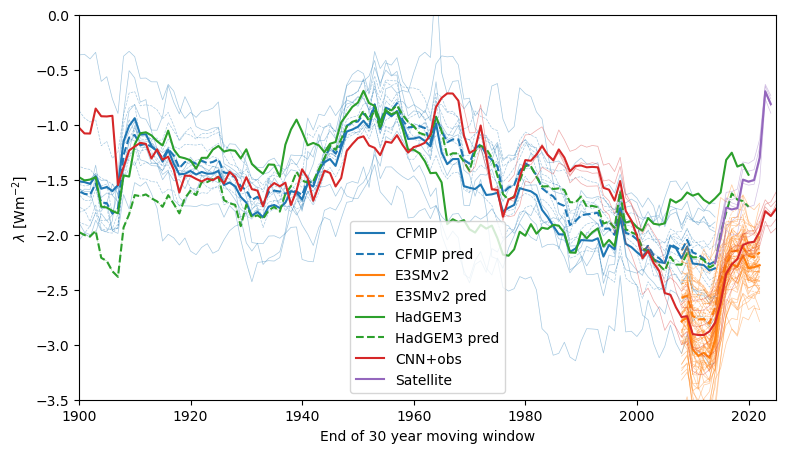

2011 1966


In [16]:
fig, ax = plt.subplots(1,1,figsize=(9,5))

for dj, (DATA_NAME, DATA_LBL) in enumerate(zip(
    DATA_NAMES, DATA_LBLS
)):
    ax.plot(model_dct[DATA_NAME]['year'][n_time-1:],model_dct[DATA_NAME]['l_true'].mean(axis=(0,1)),color=plotting.npcols[dj],label=DATA_LBL)
    ax.plot(model_dct[DATA_NAME]['year'][n_time-1:],model_dct[DATA_NAME]['l_pred'].mean(axis=(0,1)),color=plotting.npcols[dj],linestyle='dashed',label=DATA_LBL+" pred")
    for jj, model in enumerate(model_dct[DATA_NAME]['config']['datamaker']['models']):

        for mm in range(model_dct[DATA_NAME]['n_mems']):
            ax.plot(model_dct[DATA_NAME]['year'][n_time-1:],model_dct[DATA_NAME]['l_true'][jj,mm,:],color=plotting.npcols[dj],alpha=0.4, linewidth=0.5)
            ax.plot(model_dct[DATA_NAME]['year'][n_time-1:],model_dct[DATA_NAME]['l_pred'][jj,mm,:],color=plotting.npcols[dj],alpha=0.4, linewidth=0.5,linestyle='dashed')

            if SAVE_FIGS:
                write_lines(
                    './figures/data/l_'+DATA_LBL+'_'+model+'_'+str(jj)+'_r'+str(mm)+'.dat',
                    model_dct[DATA_NAME]['year'][n_time-1:],
                    model_dct[DATA_NAME]['l_true'][jj,mm,:]
                )
                write_lines(
                    './figures/data/l_pred_'+NETW_NAME+'_'+DATA_LBL+'_'+model+'_'+str(jj)+'_r'+str(mm)+'.dat',
                    model_dct[DATA_NAME]['year'][n_time-1:],
                    model_dct[DATA_NAME]['l_pred'][jj,mm,:]
                )

    if SAVE_FIGS:
        write_lines(
            './figures/data/l_'+DATA_LBL+'_avg.dat',
            model_dct[DATA_NAME]['year'][n_time-1:],
            model_dct[DATA_NAME]['l_true'].mean(axis=(0,1))
        )
        write_lines(
            './figures/data/l_pred_'+NETW_NAME+'_'+DATA_LBL+'_avg.dat',
            model_dct[DATA_NAME]['year'][n_time-1:],
            model_dct[DATA_NAME]['l_pred'].mean(axis=(0,1))
        )


ax.plot(
    obs_dict['all_l_yrs'], 
    np.nanmean(obs_dict['all_l_obs'],axis=0), 
    color=plotting.npcols[3],
    label="CNN+obs",
)

ax.plot(
    CERES_dct['year'][n_time-1:], 
    CERES_dct['l'].mean(axis=0), 
    color=plotting.npcols[4],
    label="Satellite",
)

for ii, obs_name in enumerate(OBS_NAMES):
    ax.plot(
        obs_dict['all_l_yrs'], 
        obs_dict['all_l_obs'][ii,:], 
        color=plotting.npcols[3],alpha=0.4, linewidth=0.5,
    )
    ax.plot(
        CERES_dct['year'][n_time-1:], 
        CERES_dct['l'][ii,:], 
        color=plotting.npcols[4],alpha=0.4, linewidth=0.5,
    )
    if SAVE_FIGS:
        write_lines(
            './figures/data/l_'+NETW_NAME+'_'+obs_name+'.dat',
            obs_dict[obs_name]['year'][n_time-1:],
            obs_dict[obs_name]['l_pred']
        )
        write_lines(
            './figures/data/l_CERES_'+obs_name+'.dat',
            CERES_dct['year'][n_time-1:], 
            CERES_dct['l'][ii,:], 
        )


if SAVE_FIGS:
    write_lines(
        './figures/data/l_'+NETW_NAME+'_obs_avg.dat',
        obs_dict['all_l_yrs'],
        np.nanmean(obs_dict['all_l_obs'],axis=0)
    )
    write_lines(
        './figures/data/l_CERES_avg.dat',
        CERES_dct['year'][n_time-1:], 
        CERES_dct['l'].mean(axis=0), 
    )

ax.legend()
ax.set_xlabel("End of 30 year moving window")
ax.set_ylabel("$\lambda$ [Wm$^{-2}$]")
ax.set_xlim(1900,2025)
ax.set_ylim(-3.5,0)

if SAVE_FIGS:
    fig.savefig("./figures/historical_feedback_"+NETW_NAME+".png",bbox_inches='tight',pad_inches = 0,dpi=300)
plt.show()


print(obs_dict['all_l_yrs'][np.argmin(np.nanmean(obs_dict['all_l_obs'],axis=0))],obs_dict['all_l_yrs'][np.argmax(np.nanmean(obs_dict['all_l_obs'],axis=0))])

In [39]:
SAVE_FIGS = False

In [38]:
if SAVE_FIGS:

    # Models
    for dj, (DATA_NAME, DATA_LBL) in enumerate(zip(
        DATA_NAMES, DATA_LBLS
    )):
        
        model_lst = model_dct[DATA_NAME]['config']['datamaker']['models']
        if DATA_LBL == 'E3SMv2':
            model_lst = [m[1:-21] for m in model_dct[DATA_NAMES[1]]['config']['datamaker']['data_periods']]

        da_l_true = xr.DataArray(
            model_dct[DATA_NAME]['l_true'],
            coords = {
                'model': model_lst,
                'member': np.arange(model_dct[DATA_NAME]['n_mems']),
                'end_year': model_dct[DATA_NAME]['year'][n_time-1:]
            },
            dims = ['model','member','end_year'],
            name = 'l_true',
            attrs= {
                'long_name': 'Feedback parameter',
                'units': 'Wm^-2 K^-1',
                'description': 'Feedback parameter computed as the slope of the regression of R vs T over a '+str(n_time)+' year moving window, using model-predicted R_true.'
            },
        )
        da_l_true = xr.DataArray(
            model_dct[DATA_NAME]['l_pred'],
            coords = {
                'model': model_lst,
                'member': np.arange(model_dct[DATA_NAME]['n_mems']),
                'end_year': model_dct[DATA_NAME]['year'][n_time-1:]
            },
            dims = ['model','member','end_year'],
            name = 'l_pred',
            attrs= {
                'long_name': 'Feedback parameter',
                'units': 'Wm^-2 K^-1',
                'description': 'Feedback parameter computed as the slope of the regression of R vs T over a '+str(n_time)+' year moving window, using CNN-predicted R_pred (CNN = '+NETW_NAME+').'
            },
        )
        da_R_true = xr.DataArray(
            model_dct[DATA_NAME]['R_true'],
            coords = {
                'model': model_lst,
                'member': np.arange(model_dct[DATA_NAME]['n_mems']),
                'year': model_dct[DATA_NAME]['year']
            },
            dims = ['model','member','year'],
            name = 'R_true',
            attrs= {
                'long_name': 'Top-of-atmosphere radiative response',
                'units': 'Wm^-2',
                'description': 'Model-predicted R.'
            },
        )
        da_R_pred = xr.DataArray(
            model_dct[DATA_NAME]['R_pred'],
            coords = {
                'model': model_lst,
                'member': np.arange(model_dct[DATA_NAME]['n_mems']),
                'year': model_dct[DATA_NAME]['year']
            },
            dims = ['model','member','year'],
            name = 'R_pred',
            attrs= {
                'long_name': 'Top-of-atmosphere radiative response',
                'units': 'Wm^-2',
                'description': 'CNN-predicted R (CNN = '+NETW_NAME+') using modeled surface temperature.'
            },
        )
        da_T = xr.DataArray(
            model_dct[DATA_NAME]['Tg'],
            coords = {
                'model': model_lst,
                'member': np.arange(model_dct[DATA_NAME]['n_mems']),
                'year': model_dct[DATA_NAME]['year']
            },
            dims = ['model','member','year'],
            name = 'T',
            attrs= {
                'long_name': 'Global mean temperature',
                'units': 'K',
                'description': 'Global mean temperature.'
            },
        )
        
        ds = xr.Dataset(
            {
                'feedback_true': da_l_true,
                'feedback_pred': da_l_true,
                'R_true': da_R_true,
                'R_pred': da_R_pred,
                'T': da_T,
            },
        )
        ds.to_netcdf("./figures/RTl_"+NETW_NAME+"_"+DATA_LBL+".nc")

    # OBSERVATIONAL DATA
    da_l = xr.DataArray(
        obs_dict['all_l_obs'],
        coords = {
            'data': list(OBS_NAMES),
            'end_year': obs_dict['all_l_yrs']
        },
        dims = ['data','end_year'],
        name = 'l',
        attrs= {
            'long_name': 'Feedback parameter',
            'units': 'Wm^-2 K^-1',
            'description': 'Feedback parameter computed as the slope of the regression of R vs T over a '+str(n_time)+' year moving window. CNN = '+NETW_NAME+' predictions for multiple observational datasets.'
        },
    )

    da_R = xr.DataArray(
        obs_dict['all_R'],
        coords = {
            'data': list(OBS_NAMES),
            'year': obs_dict['all_yrs']
        },
        dims = ['data','year'],
        name = 'R',
        attrs= {
            'long_name': 'Top-of-atmosphere radiative response',
            'units': 'Wm^-2',
            'description': 'CNN = '+NETW_NAME+' predictions for multiple observational datasets.'
        },
    )

    da_T = xr.DataArray(
        obs_dict['all_T'],
        coords = {
            'data': list(OBS_NAMES),
            'year': obs_dict['all_yrs']
        },
        dims = ['data','year'],
        name = 'T',
        attrs= {
            'long_name': 'Global mean temperature',
            'units': 'K',
            'description': 'Global mean temperature for multiple observational datasets.'
        },
    )

    ds = xr.Dataset(
        {
            'feedback': da_l,
            'R': da_R,
            'T': da_T,
        },
    )

    ds.to_netcdf("./figures/RTl_"+NETW_NAME+"_reconstructions.nc")

CFMIP correlation: 0.755
E3SMv2 correlation: 0.842
HadGEM3 correlation: 0.452
CFMIP3 mean correlation: 0.957


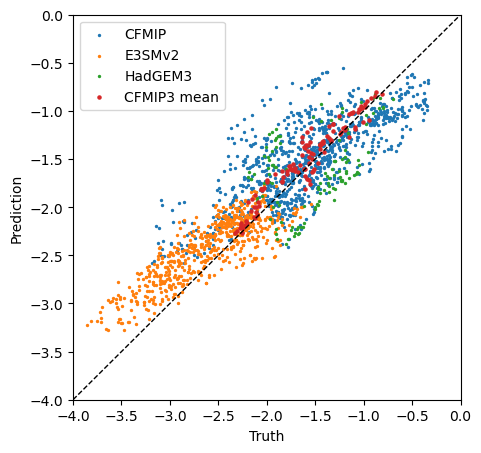

In [42]:
fig, ax = plt.subplots(1,1,figsize=(5,5))
ax.plot([-4,0],[-4,0],'k--',linewidth=1)

for dj, (DATA_NAME, DATA_LBL) in enumerate(zip(
    DATA_NAMES, DATA_LBLS
)):
    ax.scatter(
        model_dct[DATA_NAME]['l_true'][:],
        model_dct[DATA_NAME]['l_pred'][:],
        label=DATA_LBL,
        color=plotting.npcols[dj],alpha=1, s=2
    )
    if SAVE_FIGS:
        write_lines(
            './figures/data/truth_vs_pred_'+NETW_NAME+'_'+DATA_LBL+'.dat',
            model_dct[DATA_NAME]['l_true'][:].flatten(),
            model_dct[DATA_NAME]['l_pred'][:].flatten()
        )

    # R2 score
    r2 = metrics.r2_score(
        model_dct[DATA_NAME]['l_true'].flatten(),
        model_dct[DATA_NAME]['l_pred'].flatten()
    )
    # print(f"{DATA_LBL} R2: {r2:.3f}")

    # Correlation coefficient
    corr = np.corrcoef(
        model_dct[DATA_NAME]['l_true'].flatten(),
        model_dct[DATA_NAME]['l_pred'].flatten(),
    )[0,1]
    print(f"{DATA_LBL} correlation: {corr:.3f}")
ax.scatter(
    model_dct[DATA_NAMES[0]]['l_true'].mean(axis=(0,1)),
    model_dct[DATA_NAMES[0]]['l_pred'].mean(axis=(0,1)),
    label='CFMIP3 mean',
    color=plotting.npcols[dj+1],alpha=1, s=5
)
r2 = metrics.r2_score(
    model_dct[DATA_NAMES[0]]['l_true'].mean(axis=(0,1)).flatten(),
    model_dct[DATA_NAMES[0]]['l_pred'].mean(axis=(0,1)).flatten()
)
# print(f"CFMIP3 mean R2: {r2:.3f}")

# Correlation coefficient
corr = np.corrcoef(
    model_dct[DATA_NAMES[0]]['l_true'].mean(axis=(0,1)).flatten(),
    model_dct[DATA_NAMES[0]]['l_pred'].mean(axis=(0,1)).flatten()
)[0,1]
print(f"CFMIP3 mean correlation: {corr:.3f}")
if SAVE_FIGS:
    write_lines(
        './figures/data/truth_vs_pred_'+NETW_NAME+'_CFMIP3_avg.dat',
        model_dct[DATA_NAMES[0]]['l_true'].mean(axis=(0,1)),
        model_dct[DATA_NAMES[0]]['l_pred'].mean(axis=(0,1)),
    )

ax.legend()
ax.set_xlabel("Truth")
ax.set_ylabel("Prediction")
ax.set_xlim(-4,0)
ax.set_ylim(-4,0)

if SAVE_FIGS:
    fig.savefig("./figures/feedback_true_vs_pred_"+NETW_NAME+".png",bbox_inches='tight',pad_inches = 0,dpi=300)
plt.show()

## Test variability

Std CFMIP: true = 0.42514, pred = 0.19024
Std E3SMv2: true = 0.30021, pred = 0.1914
Std CNN+obs, pred = 0.17


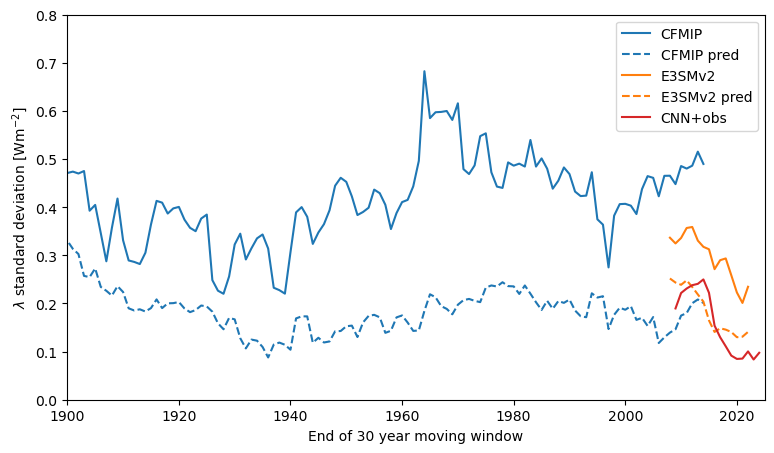

In [43]:
fig, ax = plt.subplots(1,1,figsize=(9,5))

for dj, (DATA_NAME, DATA_LBL) in enumerate(zip(
    DATA_NAMES, DATA_LBLS
)):
    
    if DATA_LBL == 'HadGEM3':
        continue

    std_true = np.std(model_dct[DATA_NAME]['l_true'],axis=(0,1))
    std_pred = np.std(model_dct[DATA_NAME]['l_pred'],axis=(0,1))

    print(\
        "Std "+DATA_LBL+\
        ": true = "+plotting.num_lab(
            np.sqrt(np.mean(std_true**2)),5)+\
        ", pred = "+plotting.num_lab(
            np.sqrt(np.mean(std_pred**2)),5)\
    )

    model_dct[DATA_NAME]['l_std_true'] = np.sqrt(np.mean(std_true**2))
    model_dct[DATA_NAME]['l_std_pred'] = np.sqrt(np.mean(std_pred**2))

    ax.plot(model_dct[DATA_NAME]['year'][n_time-1:],std_true,color=plotting.npcols[dj],label=DATA_LBL)
    ax.plot(model_dct[DATA_NAME]['year'][n_time-1:],std_pred,color=plotting.npcols[dj],linestyle='dashed',label=DATA_LBL+" pred")
    
ax.plot(
    obs_dict['all_l_yrs_overlap'], 
    np.nanstd(obs_dict['all_l_obs_overlap'],axis=0), 
    color=plotting.npcols[3],
    label="CNN+obs",
)
print(\
    "Std CNN+obs"+\
    ", pred = "+plotting.num_lab(
        np.sqrt(np.nanmean(np.nanstd(obs_dict['all_l_obs_overlap'],axis=0)**2)),2)\
)
        
ax.legend()
ax.set_xlabel("End of 30 year moving window")
ax.set_ylabel("$\lambda$ standard deviation [Wm$^{-2}$]")
ax.set_xlim(1900,2025)
ax.set_ylim(0,0.8)

if SAVE_FIGS:
    fig.savefig("./figures/historical_std_"+NETW_NAME+".png",bbox_inches='tight',pad_inches = 0,dpi=300)
plt.show()


In [48]:
# Total (model differences, IV, temperature dataset): 
#     model_dct['tas2Rg_amip_data']['l_std_true']
# Only IV and temperature dataset:
#     model_dct['tas2Rg_amip_extended_data']['l_std_true'] 

sAMIP = model_dct['tas2Rg_amip_data']['l_std_true']
sE3SM = model_dct['tas2Rg_amip_extended_E3SM']['l_std_true']
R_model = 1-(sE3SM/sAMIP)**2

print("R2 model differences: "+plotting.num_lab(R_model*100,3)+"%")

# Total (model differences, IV, temperature dataset): 
#     model_dct['tas2Rg_amip_data']['l_std_true']
# Only temperature dataset:
#     model_dct['tas2Rg_amip_data']['l_std_pred'] 
#     model_dct['tas2Rg_amip_extended_E3SM']['l_std_pred'] 
#     np.std(model_dct['tas2Rg_amip_extended_E3SM']['l_true'].mean(axis=1),axis=(0))
#   ->std(obs_dict['all_l_obs_overlap'])

sAMIP = model_dct['tas2Rg_amip_data']['l_std_true']
# sPred = model_dct['tas2Rg_amip_data']['l_std_pred']
# sPred = model_dct['tas2Rg_amip_extended_E3SM']['l_std_pred']
# sPred = np.sqrt((np.std(model_dct['tas2Rg_amip_extended_E3SM']['l_true'].mean(axis=1),axis=(0))**2).mean())
sPred = np.sqrt(np.nanmean(np.nanstd(obs_dict['all_l_obs_overlap'],axis=0)**2))

R_pred = 1-(sPred/sAMIP)**2
print("R2 model differences and internal variability: "+plotting.num_lab(R_pred*100,3)+"%")

R2 model differences: 50.1%
R2 model differences and internal variability: 83.8%


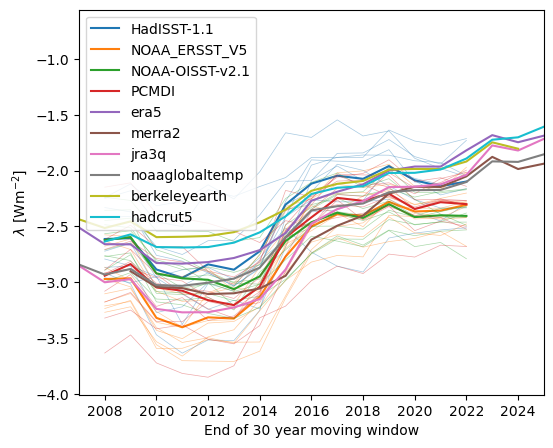

In [50]:
fig, ax = plt.subplots(1,1,figsize=(6,5))

for dj, (DATA_NAME, DATA_LBL) in enumerate(zip(
    DATA_NAMES, DATA_LBLS
)):
    
    if DATA_LBL == 'HadGEM3':
        continue
    if DATA_LBL == 'CFMIP':
        continue

    for jj, dataset in enumerate(model_dct[DATA_NAME]['config']['datamaker']['data_periods']):
        ax.plot(
            model_dct[DATA_NAME]['year'][n_time-1:],
            model_dct[DATA_NAME]['l_true'][jj,:,:].mean(axis=0),
            color=plotting.npcols[jj],
            label=dataset[1:-21]
        )

        if SAVE_FIGS:
            write_lines(
                './figures/data/l_'+DATA_LBL+'_'+dataset[1:-21]+'_'+str(jj)+'_avg.dat',
                model_dct[DATA_NAME]['year'][n_time-1:],
                model_dct[DATA_NAME]['l_true'][jj,:,:].mean(axis=0)
            )
        for mm in range(model_dct[DATA_NAME]['n_mems']):

            ax.plot(
                model_dct[DATA_NAME]['year'][n_time-1:],
                model_dct[DATA_NAME]['l_true'][jj,mm,:],
                color=plotting.npcols[jj],
                alpha=0.4,linewidth=0.5,
            )

# OBS
for ii, obs_name in enumerate(OBS_NAMES):
    if obs_dict[obs_name]['config']['datamaker']['multi_mem']:
        ax.plot(
            obs_dict[obs_name]['year'][0,n_time-1:], 
            obs_dict[obs_name]['l_pred'].mean(axis=0), 
            color=plotting.npcols[4+ii],
            label=obs_name,
        )
    else:
        ax.plot(
            obs_dict[obs_name]['year'][n_time-1:], 
            obs_dict[obs_name]['l_pred'], 
            color=plotting.npcols[4+ii],
            label=obs_name,
        )

ax.legend()
ax.set_xlabel("End of 30 year moving window")
ax.set_ylabel("$\lambda$ [Wm$^{-2}$]")
ax.set_xlim(2007,2025)

plt.show()

## SHAP plots

In [53]:
def save_map(figname,lon,lat,x,norm,crs,cmap):
    if SAVE_FIGS:
        fig, ax = plotting.setup_figure("global",nCols=1,nRows=1,size=(10,8),mask=False)
        ax.pcolormesh(lon,lat,x,norm=norm,transform=crs,cmap=cmap)

        if enso:
            fig.savefig(figname+'_no_'+enso+'.png',bbox_inches='tight',pad_inches = 0,dpi=300)
        else:
            fig.savefig(figname+'.png',bbox_inches='tight',pad_inches = 0,dpi=300)
        plt.close()

# colorbar range
l_T = np.linspace(-5,5,41)
t_T = np.linspace(-5,5,5)
cmap_T = cm.fusion_r
norm_T = mpl.colors.BoundaryNorm(l_T, cmap_T.N)

l_shap = np.linspace(-16,16,19)
t_shap = np.linspace(-16,16,5)
cmap_shap = plotting.MinMax
norm_shap = mpl.colors.BoundaryNorm(l_shap, cmap_shap.N)

### Observations

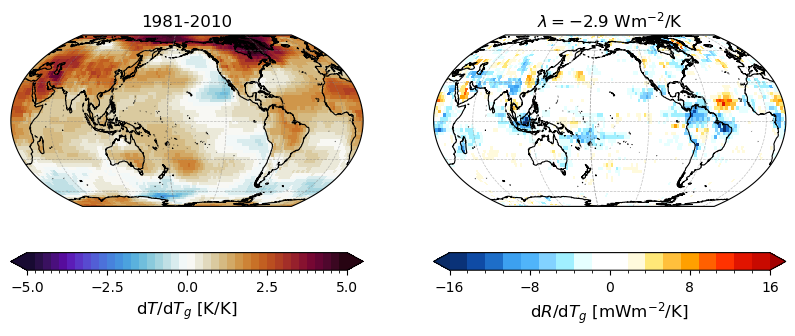

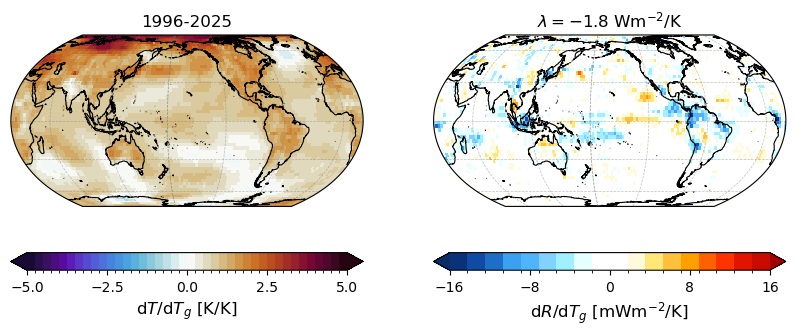

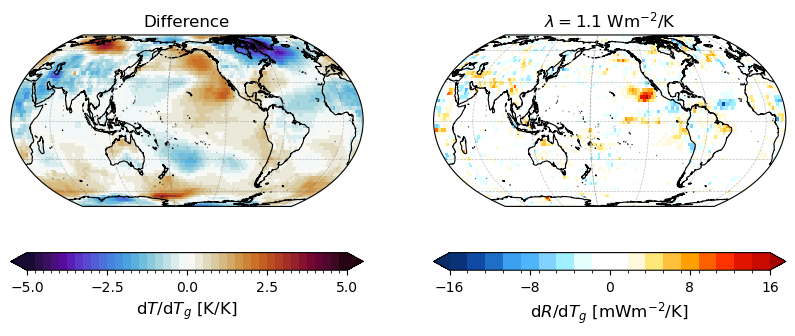

In [54]:
# end_years = [1980, 2010]
# end_years = [2010, 2022]
end_years = [2010, 2025]

shaps = [{}, {}]
for yy, end_year in enumerate(end_years):
    
    # Get year index
    iy = np.where(obs_dict['all_l_yrs'] == end_year)[0]
    if iy.size == 0:
        continue
    iy = iy[0]

    # Load patterns
    shaps[yy]['T_pattern'] = np.nanmean(obs_dict['all_T_obs'][:,iy,:,:],axis=0)
    shaps[yy]['shap_pattern'] = np.nanmean(obs_dict['all_shap_obs'][:,iy,:,:],axis=0)
    shaps[yy]['l_pred'] = np.nanmean(obs_dict['all_l_obs'][:,iy])

    # Setup figure
    fig, ax = plotting.setup_figure(
        'global',nCols=2,nRows=1,size=(10,4),mask=False
    )

    # Temperature pattern
    ax[0].set_title(str(end_year-n_time+1) + "-" + str(end_year))
    cf = ax[0].pcolormesh(
        lon,lat,shaps[yy]['T_pattern'],
        transform=plotting.data_crs, 
        cmap=cmap_T ,norm=norm_T
    )
    cb = plt.colorbar(
        cf,ax=ax[0], 
        orientation = "horizontal", shrink=1.0, 
        extend='both',ticks=t_T
    )
    cb.set_label('d$T$/d$T_g$ [K/K]', fontsize=12)

    save_map(
        './figures/T_pattern_obs_'+str(end_year-n_time+1)+"-"+str(end_year),
        lon,
        lat,
        shaps[yy]['T_pattern'],
        norm_T,
        plotting.data_crs,
        cmap_T
    )

    # SHAP pattern
    ax[1].set_title(
        "$\lambda = "+plotting.num_lab(shaps[yy]['l_pred'],2)+"$ Wm$^{-2}$/K"
    )
    cf = ax[1].pcolormesh(
        lon,lat,1e3*shaps[yy]['shap_pattern'],
        transform=plotting.data_crs, 
        cmap=cmap_shap ,norm=norm_shap
    )
    cb = plt.colorbar(
        cf,ax=ax[1], 
        orientation = "horizontal", shrink=1.0, 
        extend='both',ticks=t_shap
    )
    cb.set_label('d$R$/d$T_g$ [mWm$^{-2}$/K]', fontsize=12)

    save_map(
        './figures/shap_pattern_obs_'+NETW_NAME+'_'+str(end_year-n_time+1)+"-"+str(end_year),
        lon,
        lat,
        1e3*shaps[yy]['shap_pattern'],
        norm_shap,
        plotting.data_crs,
        cmap_shap
    )


# Setup figure
fig, ax = plotting.setup_figure(
    'global',nCols=2,nRows=1,size=(10,4),mask=False
)

# Temperature pattern
ax[0].set_title("Difference")
cf = ax[0].pcolormesh(
    lon,lat,shaps[1]['T_pattern']-shaps[0]['T_pattern'],
    transform=plotting.data_crs, 
    cmap=cmap_T ,norm=norm_T
)
cb = plt.colorbar(
    cf,ax=ax[0], 
    orientation = "horizontal", shrink=1.0, 
    extend='both',ticks=t_T
)
cb.set_label('d$T$/d$T_g$ [K/K]', fontsize=12)

save_map(
    './figures/T_pattern_diff_obs_'+str(end_years[1])+"-"+str(end_years[0]),
    lon,
    lat,
    shaps[1]['T_pattern']-shaps[0]['T_pattern'],
    norm_T,
    plotting.data_crs,
    cmap_T
)

# SHAP pattern
ax[1].set_title(
    "$\lambda = "+plotting.num_lab(shaps[1]['l_pred']-shaps[0]['l_pred'],2)+"$ Wm$^{-2}$/K"
)
cf = ax[1].pcolormesh(
    lon,lat,1e3*(shaps[1]['shap_pattern']-shaps[0]['shap_pattern']),
    transform=plotting.data_crs, 
    cmap=cmap_shap ,norm=norm_shap
)
cb = plt.colorbar(
    cf,ax=ax[1], 
    orientation = "horizontal", shrink=1.0, 
    extend='both',ticks=t_shap
)
cb.set_label('d$R$/d$T_g$ [mWm$^{-2}$/K]', fontsize=12)

save_map(
    './figures/shap_pattern_diff_obs_'+NETW_NAME+'_'+str(end_years[1])+"-"+str(end_years[0]),
    lon,
    lat,
    1e3*(shaps[1]['shap_pattern']-shaps[0]['shap_pattern']),
    norm_shap,
    plotting.data_crs,
    cmap_shap
)

## Land surface effects

In [56]:
mask = xr.open_dataarray(SHAPE_DIRECTORY + "mask_all.nc").values.astype(bool)

for DATA_NAME in DATA_NAMES:

    # Load shapes
    n_models = model_dct[DATA_NAME]['n_models']
    n_mems = model_dct[DATA_NAME]['n_mems']
    yr_amip = model_dct[DATA_NAME]['year']
    num_y = yr_amip.size

    if DATA_NAME == 'tas2Rg_amip_extended_E3SM':
        # Load amip tas data
        tas_amip = model_dct[DATA_NAME]['data'].d_test['x'].reshape((n_models,n_mems,num_y,1,lat.size,lon.size))
        tas_avg_all_sst = np.nanmean(tas_amip,axis=(1))

        # Replace ocean gridpoints with average data
        tas_avgamip = tas_amip.copy()
        for ii in range(n_models):
            tas_avg = tas_avg_all_sst[ii,:,:,:]
            for jj in range(n_mems):

                amip_tas = tas_amip[ii,jj,:,:,:,:].copy()
                amip_tas[:,:,mask] = tas_avg[:,:,mask]

                tas_avgamip[ii,jj,:,:,:,:] = amip_tas
    else:
        # Load amip tas data
        tas_amip = model_dct[DATA_NAME]['data'].d_test['x'].reshape((n_models,n_mems,num_y,1,lat.size,lon.size))
        tas_avg = np.nanmean(tas_amip,axis=(0,1))

        # Replace ocean gridpoints with average data
        tas_avgamip = tas_amip.copy()
        for ii in range(n_models):
            for jj in range(n_mems):

                amip_tas = tas_amip[ii,jj,:,:,:,:].copy()
                amip_tas[:,:,mask] = tas_avg[:,:,mask]

                tas_avgamip[ii,jj,:,:,:,:] = amip_tas

    # Create dataset
    d_tas = SampleDict()
    d_tas['x'] = tas_avgamip.reshape((n_models*n_mems*num_y,1,lat.size,lon.size))
    d_tas['y'] = np.full((n_models*n_mems*num_y,1), np.nan)
    ds_tas = MapToValueData(d_tas)

    # Predictions
    pred_obsamip = load_utils.make_predictions(
        model_dct['network']['model'], 
        dataset=ds_tas, 
        device='mps'
    )

    # Save predictions
    model_dct[DATA_NAME]['R_pred_ocean_avg'] = pred_obsamip.reshape((n_models,n_mems,num_y))

    # Load global T and R
    T = model_dct[DATA_NAME]['Tg']
    pred = model_dct[DATA_NAME]['R_pred_ocean_avg']

    # Compute linear regression coefficients
    l_true = np.empty((n_models,n_mems,num_y-n_time+1))
    l_pred = np.empty((n_models,n_mems,num_y-n_time+1))
    for ii in range(n_models):
        for jj in range(n_mems):
            for iy in range(num_y-n_time+1):
                l_pred[ii,jj,iy], _ = utils.linear_regression(T[ii,jj,iy:iy+n_time],pred[ii,jj,iy:iy+n_time])
    model_dct[DATA_NAME]['l_pred_ocean_avg'] = l_pred


In [57]:
# OBS
mask = xr.open_dataarray(SHAPE_DIRECTORY + "mask_all.nc").values.astype(bool)

yr_overlap = [1980,2024]
yrs = np.arange(yr_overlap[0],yr_overlap[1]+1)
n_mems = len(OBS_NAMES)
num_y = yrs.size

# yrs 
tas_obs_all = np.empty((n_mems,num_y,1,lat.size,lon.size))
T_obs_all = np.empty((n_mems,num_y))
R_obs_all = np.empty((n_mems,num_y))
for ii, obs_name in enumerate(OBS_NAMES):

    yr_obs = obs_dict[obs_name]['year']
    iy_ = np.where(
        np.logical_and(
            yr_obs >= yr_overlap[0],
            yr_obs <= yr_overlap[1]
        )
    )[0]
    tas_obs_all[ii,:,:,:,:] = obs_dict[obs_name]['data'].d_obs['x'][iy_,:,:,:]

    T_obs_all[ii,:] = obs_dict[obs_name]['Tg'][iy_]
    R_obs_all[ii,:] = obs_dict[obs_name]['R_pred'][iy_]

tas_avg = np.nanmean(tas_obs_all,axis=(0))

# Replace ocean gridpoints with obs data
tas_ocean_avg = tas_obs_all.copy()
for jj in range(n_mems):

    obs_tas = tas_obs_all[jj,:,:,:,:].copy()
    obs_tas[:,:,mask] = tas_avg[:,:,mask]
    # obs_tas = tas_obs_all[jj,:,:,:,:].copy()
    # obs_tas[:,:,mask] = 0.

    tas_ocean_avg[jj,:,:,:,:] = obs_tas

# Create dataset
d_tas = SampleDict()
d_tas['x'] = tas_ocean_avg.reshape((n_mems*num_y,1,lat.size,lon.size))
d_tas['y'] = np.full((n_mems*num_y,1), np.nan)
ds_tas = MapToValueData(d_tas)

# Predictions
pred_ocean_avg = load_utils.make_predictions(
    model_dct['network']['model'], 
    dataset=ds_tas, 
    device='mps'
)

# Save predictions
obs_dict['all'] = {}
obs_dict['all']['R_pred_ocean_avg'] = pred_ocean_avg.reshape((n_mems,num_y))
obs_dict['all']['year'] = yrs
obs_dict['all']['Tg'] = T_obs_all
obs_dict['all']['R_pred'] = R_obs_all

# Load global T and R
T = obs_dict['all']['Tg']
true = obs_dict['all']['R_pred']
pred_ocean = obs_dict['all']['R_pred_ocean_avg']

# Compute linear regression coefficients
l_true = np.empty((n_mems,num_y-n_time+1))
l_pred_ocean = np.empty((n_mems,num_y-n_time+1))
for jj in range(n_mems):
    for iy in range(num_y-n_time+1):
        l_true[jj,iy], _ = utils.linear_regression(T[jj,iy:iy+n_time],true[jj,iy:iy+n_time])
        l_pred_ocean[jj,iy], _ = utils.linear_regression(T[jj,iy:iy+n_time],pred_ocean[jj,iy:iy+n_time])
obs_dict['all']['l_pred'] = l_true
obs_dict['all']['l_pred_ocean_avg'] = l_pred_ocean

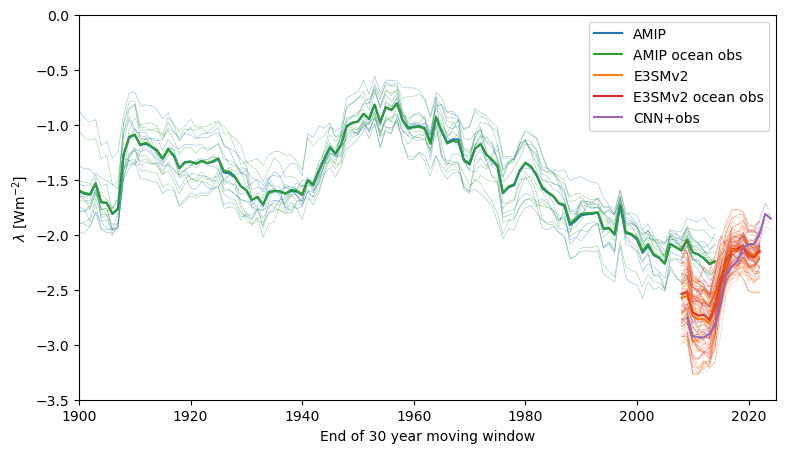

In [58]:
fig, ax = plt.subplots(1,1,figsize=(9,5))

for dj, (DATA_NAME, DATA_LBL) in enumerate(zip(
    DATA_NAMES, ('AMIP', 'E3SMv2', 'HadGEM3')
)):
    if DATA_LBL == 'HadGEM3':
        continue
    ax.plot(model_dct[DATA_NAME]['year'][n_time-1:],model_dct[DATA_NAME]['l_pred'].mean(axis=(0,1)),color=plotting.npcols[dj],label=DATA_LBL)
    ax.plot(model_dct[DATA_NAME]['year'][n_time-1:],model_dct[DATA_NAME]['l_pred_ocean_avg'].mean(axis=(0,1)),color=plotting.npcols[dj+2],label=DATA_LBL+" ocean obs")
    for jj, model in enumerate(model_dct[DATA_NAME]['config']['datamaker']['models']):

        for mm in range(model_dct[DATA_NAME]['n_mems']):
            ax.plot(model_dct[DATA_NAME]['year'][n_time-1:],model_dct[DATA_NAME]['l_pred'][jj,mm,:],color=plotting.npcols[dj],alpha=0.4, linewidth=0.5)
            ax.plot(model_dct[DATA_NAME]['year'][n_time-1:],model_dct[DATA_NAME]['l_pred_ocean_avg'][jj,mm,:],color=plotting.npcols[dj+2],alpha=0.4, linewidth=0.5)


# OBS
ax.plot(
    obs_dict['all']['year'][n_time-1:], 
    np.nanmean(obs_dict['all']['l_pred_ocean_avg'],axis=0), 
    color=plotting.npcols[4],
    label="CNN+obs",
)
ax.plot(
    obs_dict['all']['year'][n_time-1:], 
    obs_dict['all']['l_pred_ocean_avg'].T, '--',
    color=plotting.npcols[4],
    alpha=0.4, linewidth=0.5
)
        
ax.legend()
ax.set_xlabel("End of 30 year moving window")
ax.set_ylabel("$\lambda$ [Wm$^{-2}$]")
ax.set_xlim(1900,2025)
ax.set_ylim(-3.5,0)
plt.show()


Std AMIP: true = 0.19024, pred = 0.17553
Std E3SMv2: true = 0.1914, pred = 0.18481
Std OBS: true = 0.1709, pred ocean = 0.11491


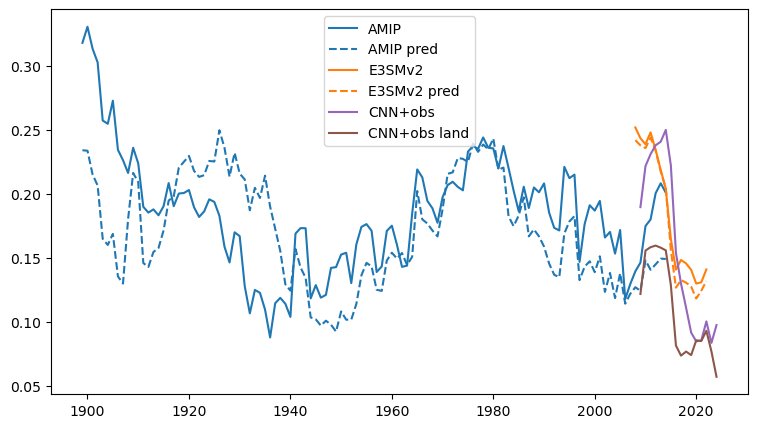

R2 ocean temperature (AMIP6): 14.9%
R2 ocean temperature (E3SM): 13.0%
R2 ocean temperature (OBS): 54.8%


In [60]:
fig, ax = plt.subplots(1,1,figsize=(9,5))

for dj, (DATA_NAME, DATA_LBL) in enumerate(zip(
    DATA_NAMES, ('AMIP', 'E3SMv2', 'HadGEM3')
)):
    
    if DATA_LBL == 'HadGEM3':
        continue

    std_true = np.std(model_dct[DATA_NAME]['l_pred'],axis=(0,1))
    std_pred = np.std(model_dct[DATA_NAME]['l_pred_ocean_avg'],axis=(0,1))

    print(\
        "Std "+DATA_LBL+\
        ": true = "+plotting.num_lab(
            np.sqrt(np.mean(std_true**2)),5)+\
        ", pred = "+plotting.num_lab(
            np.sqrt(np.mean(std_pred**2)),5)\
    )

    model_dct[DATA_NAME]['l_std_pred'] = np.sqrt(np.mean(std_true**2))
    model_dct[DATA_NAME]['l_std_pred_ocean_avg'] = np.sqrt(np.mean(std_pred**2))

    ax.plot(model_dct[DATA_NAME]['year'][n_time-1:],std_true,color=plotting.npcols[dj],label=DATA_LBL)
    ax.plot(model_dct[DATA_NAME]['year'][n_time-1:],std_pred,color=plotting.npcols[dj],linestyle='dashed',label=DATA_LBL+" pred")
    

# OBS
ax.plot(
    obs_dict['all']['year'][n_time-1:], 
    np.nanstd(obs_dict['all']['l_pred'],axis=0), 
    color=plotting.npcols[4],
    label="CNN+obs",
)  
ax.plot(
    obs_dict['all']['year'][n_time-1:], 
    np.nanstd(obs_dict['all']['l_pred_ocean_avg'],axis=0), 
    color=plotting.npcols[5],
    label="CNN+obs land",
)
ax.legend()

obs_dict['all']['l_std_pred'] = np.sqrt(np.mean(
    np.std(obs_dict['all']['l_pred'],axis=0)**2
))
obs_dict['all']['l_std_pred_ocean_avg'] = np.sqrt(np.mean(
    np.std(obs_dict['all']['l_pred_ocean_avg'],axis=0)**2
))

print("Std OBS: true = "+plotting.num_lab(
    obs_dict['all']['l_std_pred'],5
)+", pred ocean = "+plotting.num_lab(
    obs_dict['all']['l_std_pred_ocean_avg'],5
)+""
)
    
plt.show()

sAMIP = model_dct['tas2Rg_amip_data']['l_std_pred']
sOOBS = model_dct['tas2Rg_amip_data']['l_std_pred_ocean_avg']
R_pred = 1-(sOOBS/sAMIP)**2
print("R2 ocean temperature (AMIP6): "+plotting.num_lab(R_pred*100,3)+"%")


sAMIP = 0.
sOOBS = 0.
for jj, dataset in enumerate(model_dct['tas2Rg_amip_extended_E3SM']['config']['datamaker']['data_periods']):
    sAMIP_tmp = np.sqrt(np.mean(
        np.std(model_dct['tas2Rg_amip_extended_E3SM']['l_pred'][jj,:,:],axis=0)**2
    ))
    sOOBS_tmp = np.sqrt(np.mean(
        np.std(model_dct['tas2Rg_amip_extended_E3SM']['l_pred_ocean_avg'][jj,:,:],axis=0)**2
    ))
    # R_pred = 1-(sOOBS_tmp/sAMIP_tmp)**2
    # print("R2 ocean temperature (E3SM "+dataset[1:-21]+"): "+plotting.num_lab(R_pred*100,3)+"%")
    sAMIP += sAMIP_tmp/len(model_dct['tas2Rg_amip_extended_E3SM']['config']['datamaker']['data_periods'])
    sOOBS += sOOBS_tmp/len(model_dct['tas2Rg_amip_extended_E3SM']['config']['datamaker']['data_periods'])
R_pred = 1-(sOOBS/sAMIP)**2
print("R2 ocean temperature (E3SM): "+plotting.num_lab(R_pred*100,3)+"%")


sAMIP = obs_dict['all']['l_std_pred']
sOOBS = obs_dict['all']['l_std_pred_ocean_avg']
R_pred = 1-(sOOBS/sAMIP)**2
print("R2 ocean temperature (OBS): "+plotting.num_lab(R_pred*100,3)+"%")


## Regions

In [61]:
def get_sum_mask(degE,degN,mask=False,cross_zero=False):

    if mask == 'ocean':
        sum_mask = xr.open_dataarray(SHAPE_DIRECTORY + "mask_all.nc").values
    elif mask == 'land':
        sum_mask = 1-xr.open_dataarray(SHAPE_DIRECTORY + "mask_all.nc").values
    else:
        sum_mask = np.ones((lat.size,lon.size))

    sum_mask[lat<degN[1],:] = 0
    sum_mask[lat>degN[0],:] = 0
    if cross_zero:
        sum_mask[:,np.logical_and(lon>degE[0],lon<degE[1])] = 0
    else:
        sum_mask[:,lon<degE[0]] = 0
        sum_mask[:,lon>degE[1]] = 0

    return sum_mask

def get_locs(loc_str):

    cross_zero = False
    if loc_str == 'SEP':
        avg_box = [-110,-40,-70,0]
        degE = [250,290]
        degN = [0,-40]
        mask = 'ocean'
    elif loc_str == 'SEA':
        avg_box = [-20,-40,20,0]
        degE = [20,340]
        degN = [0,-40]
        mask = 'ocean'
        cross_zero = True
    elif loc_str == 'NEP':
        avg_box = [-150,10,-105,35]
        degE = [210,255]
        degN = [35,10]
        mask = 'ocean'
    elif loc_str == 'SO':
        avg_box = [np.nan,-90,np.nan,-45]
        degE = [np.nan,np.nan]
        degN = [-45,-90]
        mask = 'ocean'
    elif loc_str == 'WPWP':
        avg_box = [90,-15,160,15]
        degE = [90,160]
        degN = [15,-15]
        mask = 'ocean'
    elif loc_str == 'IO':
        avg_box = [50,-60,120,5]
        degE = [50,120]
        degN = [5,-60]
        mask = 'ocean'
    elif loc_str == 'NA':
        avg_box = [-70,5,-10,70]
        degE = [290,350]
        degN = [70,5]
        mask = 'ocean'
    elif loc_str == 'all':
        avg_box = [np.nan,-90,np.nan,90]
        degE = [np.nan,np.nan]
        degN = [90,-90]
        mask = False
    elif loc_str == 'ocean':
        avg_box = [np.nan,-90,np.nan,90]
        degE = [np.nan,np.nan]
        degN = [90,-90]
        mask = 'ocean'
    elif loc_str == 'land':
        avg_box = [np.nan,-90,np.nan,90]
        degE = [np.nan,np.nan]
        degN = [90,-90]
        mask = 'land'
    elif loc_str == 'nino3':
        avg_box = [210,-5,270,5]
        degE = [210,270]
        degN = [5,-5]
        mask = 'ocean'
    elif loc_str == 'nino4':
        avg_box = [160,-5,210,5]
        degE = [160,210]
        degN = [5,-5]
        mask = 'ocean'
    elif loc_str == 'nino34':
        avg_box = [190,-5,240,5]
        degE = [190,240]
        degN = [5,-5]
        mask = 'ocean'
    else:
        raise ValueError("Location string not recognized: "+loc_str)
        
    return avg_box, degE, degN, mask, cross_zero

In [62]:
for loc_str in ('SEP','SEA','NEP','SO','WPWP','IO','NA','all','ocean','land','nino3','nino4','nino34'):

    avg_box, degE, degN, mask, cross_zero = get_locs(loc_str)

    sum_mask = get_sum_mask(degE,degN,mask=mask, cross_zero=cross_zero)

    # AMIP data
    for dj, (DATA_NAME, DATA_LBL) in enumerate(zip(
        DATA_NAMES, DATA_LBLS
    )):

        # Get values
        years =  model_dct[DATA_NAME]['year'].copy()
        shap_pattern = model_dct[DATA_NAME]['shap_pattern']
        # n_models, n_mems, num_y, _, _ = shap_pattern.shape

        model_dct[DATA_NAME]['l_pred_'+loc_str] = np.nansum(shap_pattern*sum_mask[None,None,None,:,:],axis=(-1,-2))


    # OBS data
    for ii, obs_name in enumerate(OBS_NAMES):
        shap_pattern = obs_dict[obs_name]['shap_pattern']

        obs_dict[obs_name]['l_pred_'+loc_str] = np.nansum(shap_pattern*sum_mask[None,:,:],axis=(-1,-2))


SEP 0.7808185064718569
SEA 0.34141468544968095
NA 0.37856063355314273
IO 0.24760937500152747
NEP 0.35096655873980775
SO -0.17588720274082428
WPWP -0.12327528510788427
nino3 0.7101149230920538
nino4 -0.6241975033404065
nino34 0.6281248503966059
all 0.9999999999999011
ocean 0.8845286486299841
land 0.7248326505990712


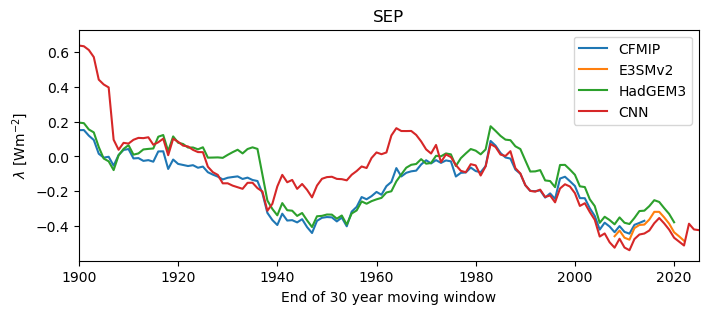

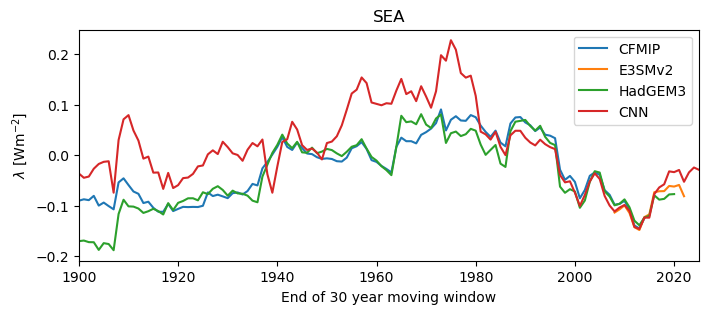

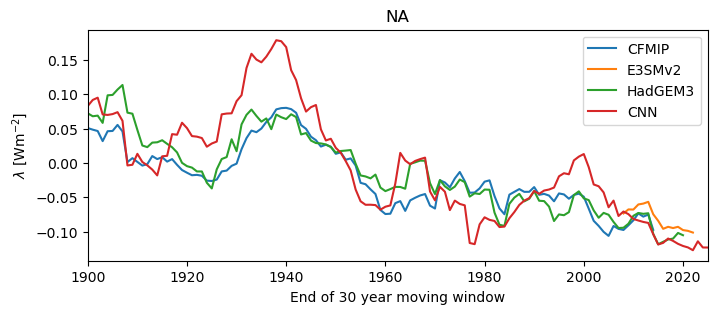

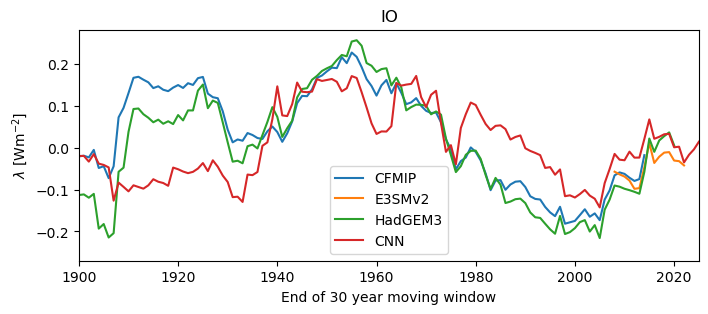

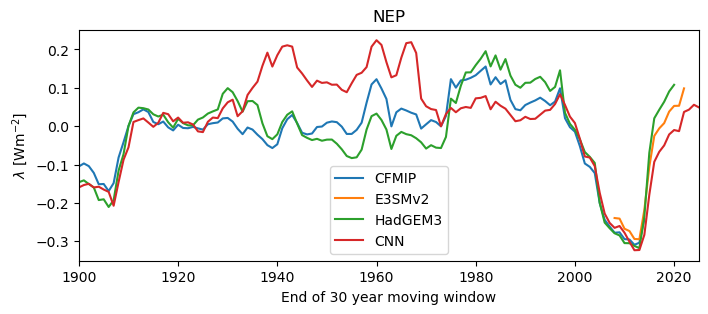

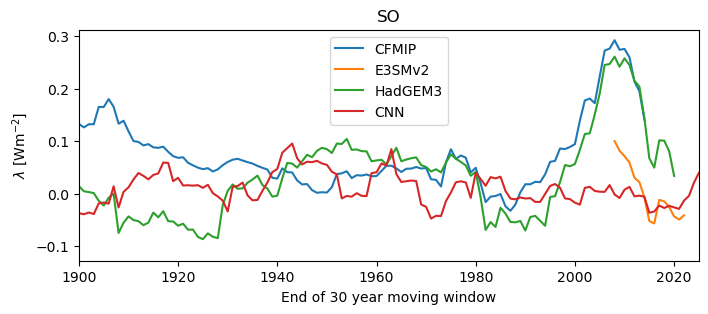

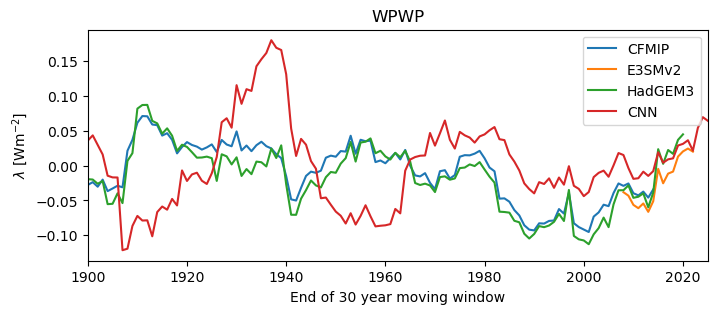

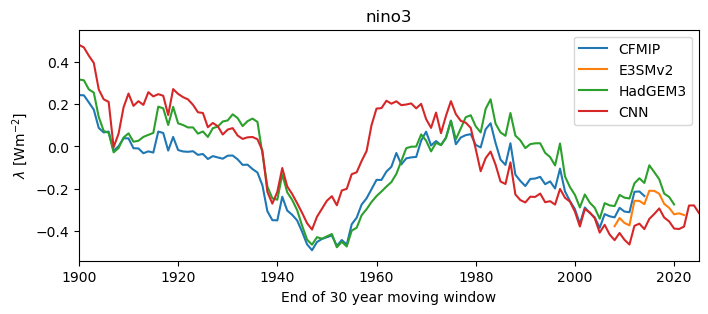

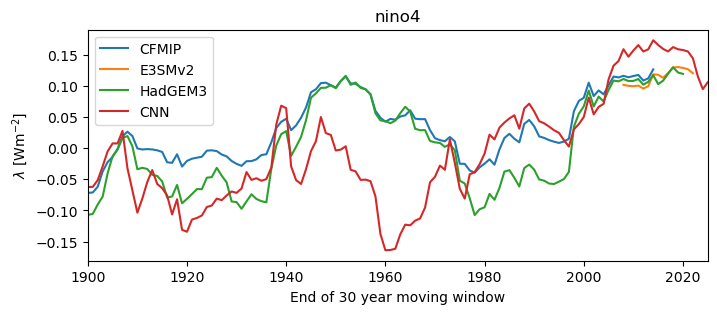

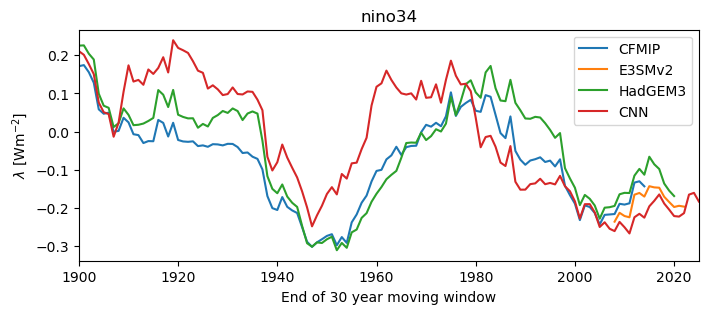

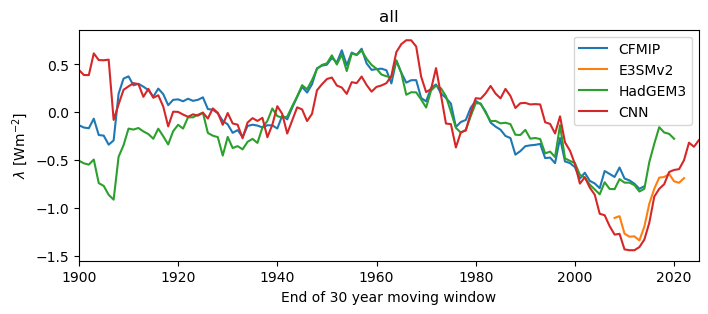

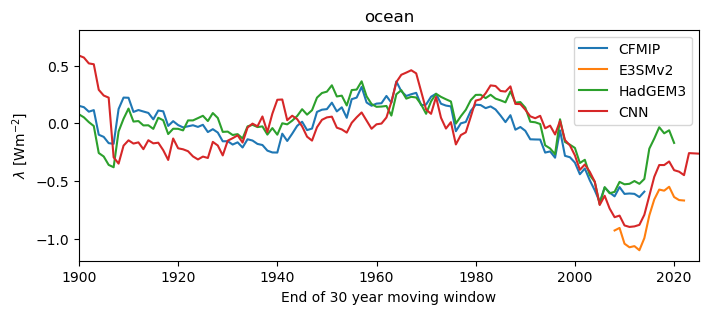

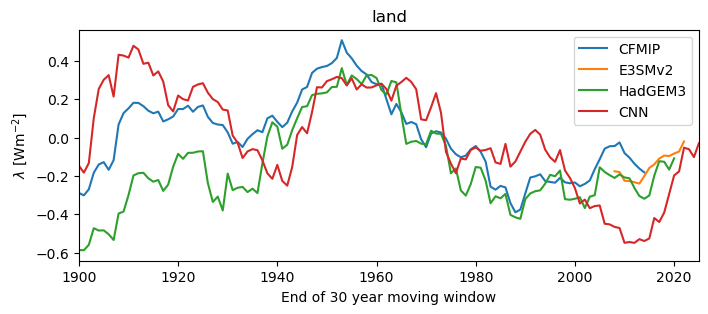

In [63]:
l_dct_locs = {}

for jj, loc_str in enumerate(('SEP','SEA','NA','IO','NEP','SO','WPWP','nino3','nino4','nino34','all','ocean','land')):

    fig, ax = plt.subplots(1,1,figsize=(8,3))

    avg_box, degE, degN, mask, cross_zero = get_locs(loc_str)

    sum_mask = get_sum_mask(degE,degN,mask=mask, cross_zero=cross_zero)
        
    all_l_yrs = np.arange(1850+n_time-1,2026)
    all_l_obs = np.full((len(OBS_NAMES),all_l_yrs.size),np.nan)
    for ii, obs_name in enumerate(OBS_NAMES):
        # Save to common array
        iy_ = np.where(
            (all_l_yrs >= obs_dict[obs_name]['l_year'][0]) & 
            (all_l_yrs <= obs_dict[obs_name]['l_year'][-1])
        )[0]
        all_l_obs[ii,iy_] = obs_dict[obs_name]['l_pred_'+loc_str]


    for dj, (DATA_NAME, DATA_LBL) in enumerate(zip(
        DATA_NAMES, DATA_LBLS
    )):
        ax.plot(
            model_dct[DATA_NAME]['year'][n_time-1:],
            model_dct[DATA_NAME]['l_pred_'+loc_str].mean(axis=(0,1))-np.nanmean(np.nanmean(all_l_obs,axis=0)),
            color=plotting.npcols[dj],
            label=DATA_LBL
        )

    ax.plot(
        all_l_yrs, 
        np.nanmean(all_l_obs,axis=0)-np.nanmean(np.nanmean(all_l_obs,axis=0)),
        color=plotting.npcols[dj+1],
        label='CNN',
    )
    l_dct_locs[loc_str] = np.nanmean(all_l_obs,axis=0)

    if SAVE_FIGS:
        all_l_loc = np.nanmean(all_l_obs,axis=0)
        all_l_loc_avg = np.nanmean(all_l_loc)
        write_lines(
            './figures/data/l_attr_'+loc_str+'_'+NETW_NAME+'_obs_avg.dat',
            all_l_yrs,
            all_l_loc-all_l_loc_avg
        )
        for ii, obs_name in enumerate(OBS_NAMES):
            write_lines(
                './figures/data/l_attr_'+loc_str+'_'+NETW_NAME+'_'+obs_name+'.dat',
                obs_dict[obs_name]['year'][n_time-1:],
                obs_dict[obs_name]['l_pred_'+loc_str]-all_l_loc_avg
            )
        if loc_str == 'all' or loc_str == 'ocean' or loc_str == 'land':
            write_lines(
                './figures/data/l_attr_abs_'+loc_str+'_'+NETW_NAME+'_obs_avg.dat',
                all_l_yrs,
                all_l_loc
            )
            for ii, obs_name in enumerate(OBS_NAMES):
                write_lines(
                    './figures/data/l_attr_abs_'+loc_str+'_'+NETW_NAME+'_'+obs_name+'.dat',
                    obs_dict[obs_name]['year'][n_time-1:],
                    obs_dict[obs_name]['l_pred_'+loc_str]
                )


    obs_pred_all = np.nanmean(obs_dict['all_l_obs'],axis=0)
    obs_pred_all = obs_pred_all - np.nanmean(obs_pred_all)
    obs_pred_loc = np.nanmean(all_l_obs,axis=0)
    obs_pred_loc = obs_pred_loc - np.nanmean(obs_pred_loc)
    print(loc_str, np.corrcoef(obs_pred_all,obs_pred_loc)[0,1])

    ax.legend()
    ax.set_title(loc_str)
    ax.set_xlabel("End of 30 year moving window")
    ax.set_ylabel("$\lambda$ [Wm$^{-2}$]")
    ax.set_xlim(1900,2025)
    # ax.set_ylim(-3.5,0)

plt.show()


nino34 0.963343832408057


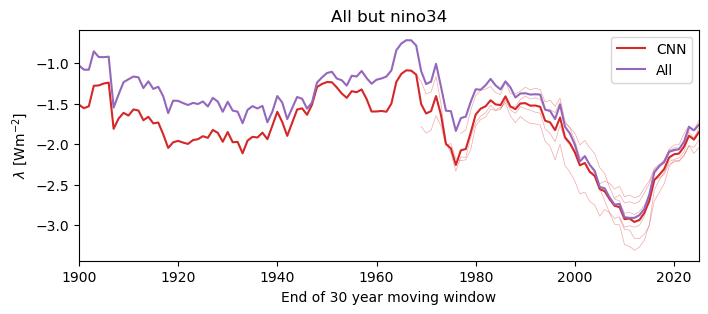

In [67]:
l_dct_locs = {}

# for jj, loc_str in enumerate(('SEP','SEA','NA','IO','NEP','SO','WPWP','nino3','nino4','nino34','all','ocean','land')):
for jj, loc_str in enumerate(('nino34',)):

    fig, ax = plt.subplots(1,1,figsize=(8,3))


    all_l_yrs = np.arange(1850+n_time-1,2026)
    all_l_obs = np.full((len(OBS_NAMES),all_l_yrs.size),np.nan)
    for ii, obs_name in enumerate(OBS_NAMES):

        # Save to common array
        iy_ = np.where(
            (all_l_yrs >= obs_dict[obs_name]['l_year'][0]) & 
            (all_l_yrs <= obs_dict[obs_name]['l_year'][-1])
        )[0]
        all_l_obs[ii,iy_] = obs_dict[obs_name]['l_pred'] - obs_dict[obs_name]['l_pred_'+loc_str]

        ax.plot(
            obs_dict[obs_name]['l_year'], 
            obs_dict[obs_name]['l_pred'] - obs_dict[obs_name]['l_pred_'+loc_str],
            color=plotting.npcols[dj+1],
            alpha=0.4, linewidth=0.5,
        )
            
    ax.plot(
        all_l_yrs, 
        np.nanmean(all_l_obs,axis=0),
        color=plotting.npcols[dj+1],
        label='CNN',
    )
    ax.plot(
        all_l_yrs, 
        np.nanmean(obs_dict['all_l_obs'],axis=0),
        color=plotting.npcols[dj+2],
        label='All',
    )

    if SAVE_FIGS:
        all_l_loc = np.nanmean(all_l_obs,axis=0)
        all_l_loc_avg = np.nanmean(all_l_loc)
        write_lines(
            './figures/data/l_attr_all_but_abs_'+loc_str+'_'+NETW_NAME+'_obs_avg.dat',
            all_l_yrs,
            all_l_loc
        )


    obs_pred_all = np.nanmean(obs_dict['all_l_obs'],axis=0)
    obs_pred_all = obs_pred_all - np.nanmean(obs_pred_all)
    obs_pred_loc = np.nanmean(all_l_obs,axis=0)
    obs_pred_loc = obs_pred_loc - np.nanmean(obs_pred_loc)
    print(loc_str, np.corrcoef(obs_pred_all,obs_pred_loc)[0,1])

    ax.legend()
    ax.set_title("All but "+loc_str)
    ax.set_xlabel("End of 30 year moving window")
    ax.set_ylabel("$\lambda$ [Wm$^{-2}$]")
    ax.set_xlim(1900,2025)
    # ax.set_ylim(-3.5,0)

plt.show()


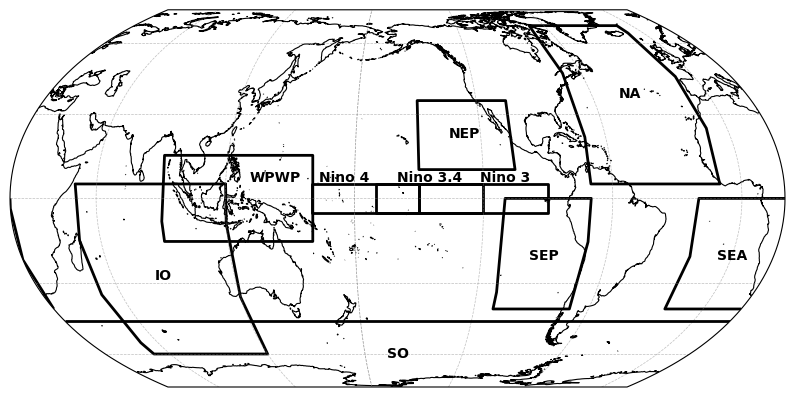

In [68]:
fig, ax = plotting.setup_figure(
    'global',nCols=1,nRows=1,size=(10,8),mask=False
)

for jj, (loc_str, loc_lbl) in enumerate(zip(
    ('SEP','SEA','NA','IO','NEP','SO','WPWP','nino3','nino4','nino34'),
    ('SEP','SEA','NA','IO','NEP','SO','WPWP','Nino 3','Nino 4','Nino 3.4'),
)):

    avg_box, degE, degN, mask, cross_zero = get_locs(loc_str)

    sum_mask = get_sum_mask(degE,degN,mask=mask, cross_zero=cross_zero)
    plotting.add_square(
        ax, avg_box,
        crs=plotting.data_crs, facecolor='none', edgecolor='black', linewidth=2
    )

    # Add text by avg_box center
    mid_lon = (avg_box[0]+avg_box[2])/2
    mid_lat = (avg_box[1]+avg_box[3])/2
    if loc_str == 'nino3':
        mid_lon += 10
        mid_lat += 7
    if loc_str == 'nino34':
        mid_lon += 0
        mid_lat += 7
    if loc_str == 'nino4':
        mid_lon += -10
        mid_lat += 7
    if loc_str == 'WPWP':
        mid_lon += 18
        mid_lat += 7
    if loc_str == 'SO':
        mid_lon = 200
        mid_lat = -60
    ax.text(
        mid_lon, mid_lat, loc_lbl,
        transform=plotting.data_crs,
        fontsize=10, fontweight='bold',
        horizontalalignment='center',
        verticalalignment='center'
    )
    if SAVE_FIGS:
        fig.savefig('./figures/def_regions.png',bbox_inches='tight',pad_inches = 0,dpi=300)

## ENSO

In [69]:
NOAA_RONI_yrs = np.arange(1950,2026)
NOAA_RONI_OND = np.array([-0.41, 0.91,-0.01, 0.81,-0.56,-1.63,-0.37, 1.52, 0.39,-0.11, 0.01,-0.24,-0.46, 1.22,-0.70, 2.04,-0.12, 0.01, 0.77, 0.74,-0.70,-0.52, 2.21,-1.95,-0.45,-1.08, 1.13, 1.09, 0.15, 0.54, 0.20,-0.19, 2.43,-1.14,-0.83,-0.09, 1.36, 1.02,-1.94,-0.15, 0.39, 1.70, 0.08, 0.28, 1.34,-0.95,-0.30, 2.36,-1.63,-1.38,-0.69,-0.25, 1.47, 0.32, 0.73,-0.50, 0.94,-1.41,-0.60, 1.34,-1.72,-1.05,-0.06,-0.22, 0.52, 2.34,-1.08,-1.15, 0.77, 0.23,-1.54,-1.23,-1.05, 1.49,-0.94,-0.93])

strong_o = list(NOAA_RONI_yrs[np.where(NOAA_RONI_OND> 1.0)[0]])
strong_a = list(NOAA_RONI_yrs[np.where(NOAA_RONI_OND<-1.0)[0]])

In [70]:
np.array(strong_o), np.array(strong_a)

(array([1957, 1963, 1965, 1972, 1976, 1977, 1982, 1986, 1987, 1991, 1994,
        1997, 2002, 2009, 2015, 2023]),
 array([1955, 1973, 1975, 1983, 1988, 1998, 1999, 2007, 2010, 2011, 2016,
        2017, 2020, 2021, 2022]))

In [71]:
def write_triple_line(f, x, y, z):
    f.write(str(x))
    f.write(" ")
    f.write(str(y))
    f.write(" ")
    f.write(str(z))
    f.write("\n")
    
def write_triple_lines(fname,x,y,z,header=None):
    with open(fname,"w") as f:
        if header is not None:
            f.write(header+"\n")
        for xx,yy,zz in zip(x,y,z):
            write_triple_line(f, xx, yy, zz)

lambda 1951-1980: -1.4 Wm^-2/K
-1.402600042374698 -0.07730218269127409
lambda_enso_free 1951-1980: -1.1 Wm^-2/K
-1.0919592612269702 -0.03616916040694568


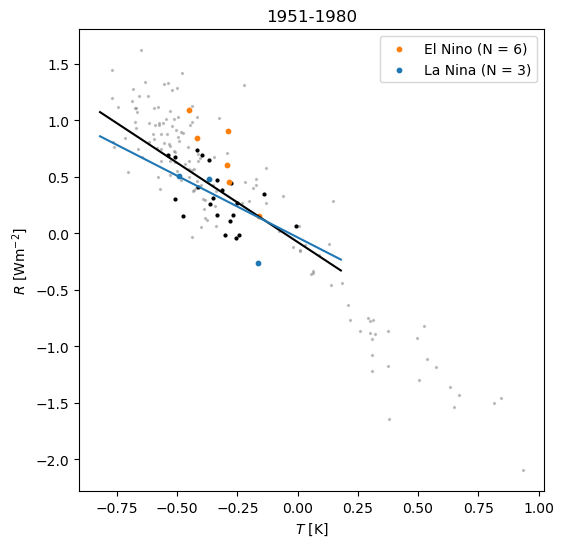

lambda 1981-2010: -2.9 Wm^-2/K
-2.9482923320428185 -0.036464993345847685
lambda_enso_free 1981-2010: -2.7 Wm^-2/K
-2.708526965861948 -0.05788238557530648


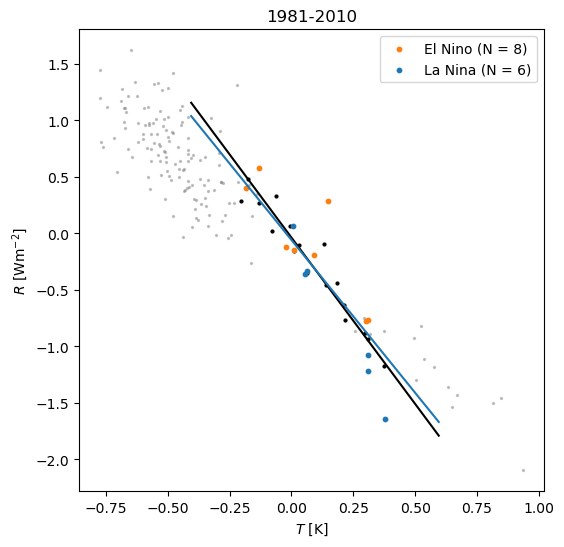

lambda 1996-2025: -1.8 Wm^-2/K
-1.769350870308104 -0.2622095740130963
lambda_enso_free 1996-2025: -1.8 Wm^-2/K
-1.8104002997897282 -0.24590694002289293


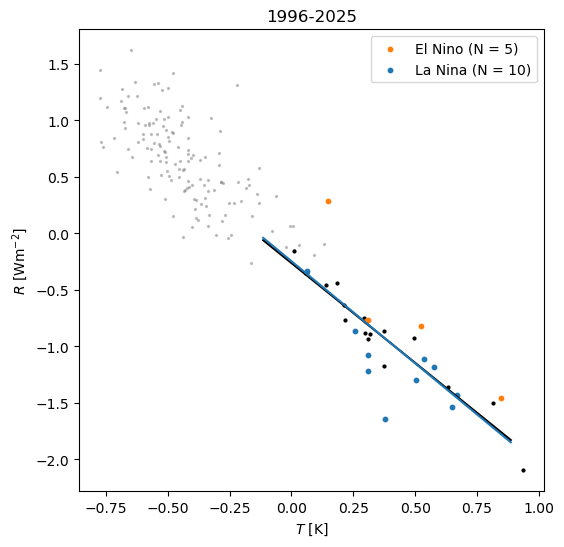

In [72]:

for end_year in (1980, 2010, 2025):

    fig, ax = plt.subplots(1,1,figsize=(6,6))
        
    all_R_yrs = np.arange(1850,2026)
    all_R_obs = np.full((len(OBS_NAMES),all_R_yrs.size),np.nan)
    all_T_obs = np.full((len(OBS_NAMES),all_R_yrs.size),np.nan)
    for ii, obs_name in enumerate(OBS_NAMES):
        if obs_dict[obs_name]['config']['datamaker']['multi_mem']:
            continue

        else:

            # Save to common array
            iy_ = np.where(
                (all_R_yrs >= obs_dict[obs_name]['year'][0]) & 
                (all_R_yrs <= obs_dict[obs_name]['year'][-1])
            )[0]
            all_R_obs[ii,iy_] = obs_dict[obs_name]['R_pred']
            all_T_obs[ii,iy_] = obs_dict[obs_name]['Tg']

    ax.scatter(
        np.nanmean(all_T_obs,axis=0), 
        np.nanmean(all_R_obs,axis=0), 
        color='gray',
        alpha=0.4, 
        s=2,
    )

    iy_ = np.where(1950 <= yr)[0]
    yr_w = all_R_yrs[iy_]
    T_w = np.nanmean(all_T_obs,axis=0)[iy_]
    R_w = np.nanmean(all_R_obs,axis=0)[iy_]


    iy_strong_o = np.where(\
        np.isin(yr_w, strong_o)
    )[0]
    iy_strong_a = np.where(\
        np.isin(yr_w, strong_a)
    )[0]

    if SAVE_FIGS:
        write_triple_lines(
            './figures/data/T_vs_R_'+NETW_NAME+'_obs_avg.dat',
            yr_w,
            T_w,
            R_w,
            header="year T R"
        )
        write_triple_lines(
            './figures/data/T_vs_R_nino_years_'+NETW_NAME+'_obs_avg.dat',
            yr_w[iy_strong_o],
            T_w[iy_strong_o],
            R_w[iy_strong_o],
            header="year T R"
        )
        write_triple_lines(
            './figures/data/T_vs_R_nina_years_'+NETW_NAME+'_obs_avg.dat',
            yr_w[iy_strong_a],
            T_w[iy_strong_a],
            R_w[iy_strong_a],
            header="year T R"
        )

    yr = all_R_yrs
    iy_ = np.where(
        (end_year-n_time <= yr) & (yr <= end_year)
    )[0]

    a, b = utils.linear_regression(
        np.nanmean(all_T_obs[:,iy_],axis=0),
        np.nanmean(all_R_obs[:,iy_],axis=0),
    )

    T_avg = np.nanmean(all_T_obs[:,iy_])
    dT = np.linspace(-0.5,0.5)
    ax.plot(T_avg+dT, a*(T_avg+dT) + b, color='k')
    print("lambda "+str(end_year-n_time+1)+"-"+str(end_year)+": "+plotting.num_lab(a,2)+" Wm^-2/K")
    print(a, b)


    ax.scatter(
        np.nanmean(all_T_obs[:,iy_],axis=0), 
        np.nanmean(all_R_obs[:,iy_],axis=0), 
        color='black',
        alpha=1, 
        s=4
    )


    yr_here = yr[iy_]
    iy_strong_o = np.where(\
        np.isin(yr_here, strong_o)
    )[0]
    iy_strong_a = np.where(\
        np.isin(yr_here, strong_a)
    )[0]
    iy_strong = np.where(\
        np.isin(yr_here, strong_a+strong_o)
    )[0]
    
    a, b = utils.linear_regression(
        np.delete(np.nanmean(all_T_obs[:,iy_],axis=0),iy_strong),
        np.delete(np.nanmean(all_R_obs[:,iy_],axis=0),iy_strong),
    )
    ax.plot(T_avg+dT, a*(T_avg+dT) + b, color=plotting.npcols[0])
    print("lambda_enso_free "+str(end_year-n_time+1)+"-"+str(end_year)+": "+plotting.num_lab(a,2)+" Wm^-2/K")
    print(a, b)

    ax.scatter(
        np.nanmean(all_T_obs[:,iy_],axis=0)[iy_strong_o], 
        np.nanmean(all_R_obs[:,iy_],axis=0)[iy_strong_o], 
        color=plotting.npcols[1],
        alpha=1, 
        s=10,
        label="El Nino (N = "+str(len(iy_strong_o))+")"
    )


    ax.scatter(
        np.nanmean(all_T_obs[:,iy_],axis=0)[iy_strong_a], 
        np.nanmean(all_R_obs[:,iy_],axis=0)[iy_strong_a], 
        color=plotting.npcols[0],
        alpha=1, 
        s=10,
        label="La Nina (N = "+str(len(iy_strong_a))+")"
    )


    ax.set_title(str(end_year-n_time+1)+"-"+str(end_year))       
    ax.legend()
    ax.set_xlabel("$T$ [K]")
    ax.set_ylabel("$R$ [Wm$^{-2}$]")

    plt.show()


### Regress ENSO from T and R globally

In [73]:
def get_mean_mask(degE,degN,mask=False,cross_zero=False):

    weights_avg = np.array([np.cos(np.deg2rad(lat))]).T
    weights_avg = np.tile(weights_avg, (1, lon.shape[0]))
    if mask == 'ocean':
        sum_mask = xr.open_dataarray(SHAPE_DIRECTORY + "mask_all.nc").values
    elif mask == 'land':
        sum_mask = 1-xr.open_dataarray(SHAPE_DIRECTORY + "mask_all.nc").values
    else:
        sum_mask = np.ones_like(weights_avg)

    sum_mask[lat<degN[1],:] = 0
    sum_mask[lat>degN[0],:] = 0
    if cross_zero:
        sum_mask[:,np.logical_and(lon>degE[0],lon<degE[1])] = 0
    else:
        sum_mask[:,lon<degE[0]] = 0
        sum_mask[:,lon>degE[1]] = 0

    weights_avg = weights_avg * sum_mask
    weights_avg = weights_avg/np.sum(weights_avg)

    return weights_avg

In [75]:
avg_box, degE, degN, mask, cross_zero = get_locs('nino34')
mean_mask = get_mean_mask(degE,degN,mask=mask, cross_zero=cross_zero)


# AMIP data
for DATA_NAME in DATA_NAMES:

    # Load T and R
    T = model_dct[DATA_NAME]['Tg']
    n_models, n_mems, num_y = T.shape[:3]
    tas =  model_dct[DATA_NAME]['data'].d_test['x'].reshape((n_models,n_mems,num_y,lat.size,lon.size))
    true = model_dct[DATA_NAME]['R_true']
    pred = model_dct[DATA_NAME]['R_pred']

    n34 = np.nansum(tas*mean_mask[None,None,None,:,:],axis=(-1,-2))

    # Remove n34
    for ii in range(n_models):
        for jj in range(n_mems):
            
            # T
            a, b = utils.linear_regression(n34[ii,jj,:], T[ii,jj,:])
            T_n = a*n34[ii,jj,:] + b
            T_n34 = T - T_n

            # R_true
            a, b = utils.linear_regression(n34[ii,jj,:], true[ii,jj,:])
            true_n = a*n34[ii,jj,:] + b
            true_n34 = true - true_n

            # R_pred
            a, b = utils.linear_regression(n34[ii,jj,:], pred[ii,jj,:])
            pred_n = a*n34[ii,jj,:] + b
            pred_n34 = pred - pred_n
    
    model_dct[DATA_NAME]['Tg_n34'] = T_n34
    model_dct[DATA_NAME]['R_true_n34'] = true_n34
    model_dct[DATA_NAME]['R_pred_n34'] = pred_n34

    # Compute linear regression coefficients
    l_true = np.empty((n_models,n_mems,num_y-n_time+1))
    l_pred = np.empty((n_models,n_mems,num_y-n_time+1))
    for ii in range(n_models):
        for jj in range(n_mems):
            for iy in range(num_y-n_time+1):
                l_true[ii,jj,iy], _ = utils.linear_regression(
                    T_n34[ii,jj,iy:iy+n_time],
                    true_n34[ii,jj,iy:iy+n_time]
                )
                l_pred[ii,jj,iy], _ = utils.linear_regression(
                    T_n34[ii,jj,iy:iy+n_time],
                    pred_n34[ii,jj,iy:iy+n_time]
                )
    model_dct[DATA_NAME]['l_true_n34'] = l_true
    model_dct[DATA_NAME]['l_pred_n34'] = l_pred

# Observational data
all_l_yrs = np.arange(1850+n_time-1,2026)
all_l_obs = np.full((len(OBS_NAMES),all_l_yrs.size),np.nan)
for ii, obs_name in enumerate(OBS_NAMES):

    # Load T and R
    T = obs_dict[obs_name]['Tg']
    pred = obs_dict[obs_name]['R_pred']

    num_y = T.shape[0]
    tas = obs_dict[obs_name]['data'].d_obs['x']
    n34 = np.nansum(tas*mean_mask[None,:,:],axis=(-1,-2))[:,0]

    # Remove n34
    # T
    a, b = utils.linear_regression(n34, T)
    T_n = a*n34 + b
    T_n34 = T - T_n

    # R_pred
    a, b = utils.linear_regression(n34, pred)
    pred_n = a*n34 + b
    pred_n34 = pred - pred_n

    obs_dict[obs_name]['Tg_n34'] = T_n34
    obs_dict[obs_name]['R_pred_n34'] = pred_n34

    # Compute linear regression coefficients
    l_pred = np.empty((num_y-n_time+1))
    for iy in range(num_y-n_time+1):
        l_pred[iy], _ = utils.linear_regression(
            T_n34[iy:iy+n_time],
            pred_n34[iy:iy+n_time]
        )
    obs_dict[obs_name]['l_pred_n34'] = l_pred

    # Corresponding years
    l_year = obs_dict[obs_name]['year'][n_time-1:]

    # Save to common array
    iy_ = np.where(
        (all_l_yrs >= obs_dict[obs_name]['l_year'][0]) & 
        (all_l_yrs <= obs_dict[obs_name]['l_year'][-1])
    )[0]
    all_l_obs[ii,iy_] = obs_dict[obs_name]['l_pred_n34']
        
obs_dict['all_l_obs_n34'] = all_l_obs


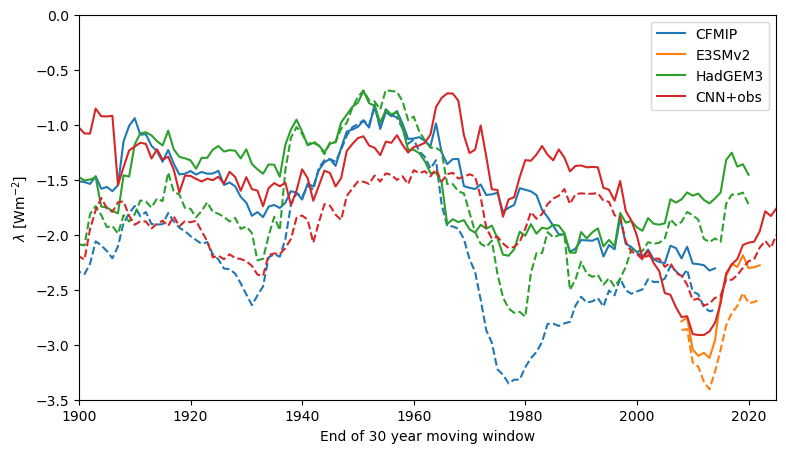

In [78]:
fig, ax = plt.subplots(1,1,figsize=(9,5))

for dj, (DATA_NAME, DATA_LBL) in enumerate(zip(
    DATA_NAMES, DATA_LBLS
)):
    ax.plot(model_dct[DATA_NAME]['year'][n_time-1:],model_dct[DATA_NAME]['l_true'].mean(axis=(0,1)),color=plotting.npcols[dj],label=DATA_LBL)
    ax.plot(model_dct[DATA_NAME]['year'][n_time-1:],model_dct[DATA_NAME]['l_true_n34'].mean(axis=(0,1)),color=plotting.npcols[dj],linestyle='dashed')

ax.plot(
    obs_dict['all_l_yrs'], 
    np.nanmean(obs_dict['all_l_obs'],axis=0), 
    color=plotting.npcols[3],
    label="CNN+obs",
)

ax.plot(
    obs_dict['all_l_yrs'], 
    np.nanmean(obs_dict['all_l_obs_n34'],axis=0), 
    color=plotting.npcols[3],
    linestyle='dashed',
)

if SAVE_FIGS:
    utils.write_lines(
        './figures/data/l_remove_n34_global_'+NETW_NAME+'_obs_avg.dat',
        obs_dict['all_l_yrs'], 
        np.nanmean(obs_dict['all_l_obs_n34'],axis=0), 
    )


ax.legend()
ax.set_xlabel("End of 30 year moving window")
ax.set_ylabel("$\lambda$ [Wm$^{-2}$]")
ax.set_xlim(1900,2025)
ax.set_ylim(-3.5,0)

plt.show()


# Observational ensembles

In [80]:
# Observational data
OBS_ENSEMBLES = (
    "hadcrut5_noaa",
    "dcent_ens",
    "forcesmip_forced",
)
obs_ens_dict = {}
for obs_name in OBS_ENSEMBLES:
    OBS_DATA_NAME = "tas_" + obs_name
    obs_ens_dict[obs_name] = {}

    (
        obs_ens_dict[obs_name]['config'],
        obs_ens_dict[obs_name]['data'],
        obs_ens_dict[obs_name]['dataset'],
    ) = load_utils.load_obs_data(OBS_DATA_NAME, seed, verbose=False, anomaly_dates = model_dct['network']['config']['datamaker']['anomaly_dates'])


# T and R
for obs_name in OBS_ENSEMBLES:

    # Global mean temperature
    (
        obs_ens_dict[obs_name]['data'].d_obs['x_gm'], 
        weights 
    ) = load_utils.get_global_mean_obs(obs_ens_dict[obs_name]['config'], seed)

    # Predictions
    GM_pred = load_utils.make_predictions(
        model_dct['network']['model'], 
        dataset=obs_ens_dict[obs_name]['dataset'], 
        device='mps'
    )

    # Save data to dict
    n_mems = obs_ens_dict[obs_name]['config']['datamaker']['n_mems']
    n_times = int(obs_ens_dict[obs_name]['data'].d_obs['y'].shape[0] / n_mems)

    obs_ens_dict[obs_name]['year'] = obs_ens_dict[obs_name]['data'].d_obs['year'].reshape((n_mems,n_times))[0,:]
    obs_ens_dict[obs_name]['Tg'] = obs_ens_dict[obs_name]['data'].d_obs['x_gm'].reshape((n_mems,n_times))
    
    obs_ens_dict[obs_name]['R_pred'] = GM_pred.reshape((n_mems,n_times))



# Feedbacks
all_l_yrs = np.arange(1850+n_time-1,2026)
all_l_obs = np.full((len(OBS_ENSEMBLES),all_l_yrs.size),np.nan)
for ii, obs_name in enumerate(OBS_ENSEMBLES):
    if obs_ens_dict[obs_name]['config']['datamaker']['multi_mem']:

        # Load T and R
        T = obs_ens_dict[obs_name]['Tg']
        pred = obs_ens_dict[obs_name]['R_pred']

        n_mems, num_y = T.shape[:2]

        # Compute linear regression coefficients
        l_pred = np.empty((n_mems,num_y-n_time+1))
        for jj in range(n_mems):
            for iy in range(num_y-n_time+1):
                l_pred[jj,iy], _ = utils.linear_regression(T[jj,iy:iy+n_time],pred[jj,iy:iy+n_time])
        obs_ens_dict[obs_name]['l_pred'] = l_pred

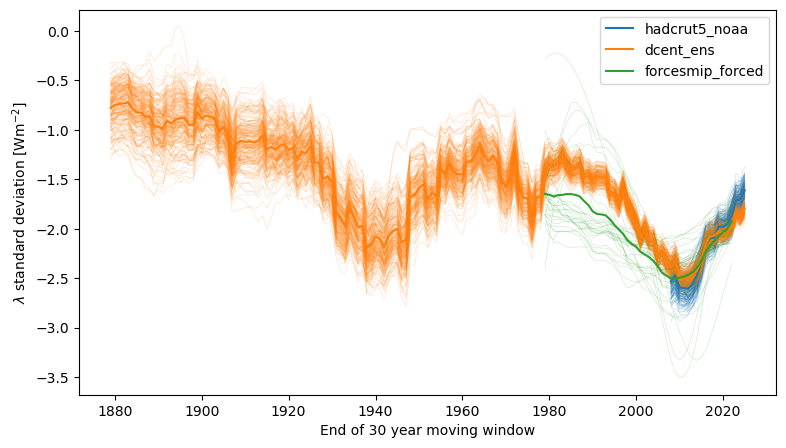

In [85]:
fig, ax = plt.subplots(1,1,figsize=(9,5))
for ii, obs_name in enumerate(OBS_ENSEMBLES):
    ax.plot(
        obs_ens_dict[obs_name]['year'][n_time-1:], 
        obs_ens_dict[obs_name]['l_pred'].T, 
        color=plotting.npcols[ii],
        alpha=0.2,linewidth=0.5,
        zorder=0,
    )
    ax.plot(
        obs_ens_dict[obs_name]['year'][n_time-1:], 
        obs_ens_dict[obs_name]['l_pred'].mean(axis=0), 
        color=plotting.npcols[ii],
        label=obs_name,
    )
    if SAVE_FIGS:
        for mm in range(obs_ens_dict[obs_name]['l_pred'].shape[0]):
            utils.write_lines(
                './figures/data/l_'+NETW_NAME+'_'+obs_name+'_r'+str(mm)+'.dat',
                obs_ens_dict[obs_name]['year'][mm,n_time-1:],
                obs_ens_dict[obs_name]['l_pred'][mm,:]
            )
        utils.write_lines(
            './figures/data/l_'+NETW_NAME+'_'+obs_name+'_avg.dat',
            obs_ens_dict[obs_name]['year'][0,n_time-1:],
            obs_ens_dict[obs_name]['l_pred'].mean(axis=0)
        )

ax.legend()
ax.set_xlabel("End of 30 year moving window")
ax.set_ylabel("$\lambda$ standard deviation [Wm$^{-2}$]")
# ax.set_xlim(2008,2025)

plt.show()